<a href="https://colab.research.google.com/github/nerdymuslim/SIG742---Modern-Data-Science/blob/GRP14-MAIN/Group14_MDS_End_Term_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border: 3px solid black; padding: 40px; text-align: center; margin: 40px;">

# **SIT742: Modern Data Science**  
## **End Term Assignment**  

<br><br>

### **Student ID:** s225743731  
### **Student Name:** Jayant Kaushal  

<br><br>

### **Assignment Type:** Group Assignment  
### **Group Name:** Group 14  

<div style="font-size:18px; font-style:italic; text-align:center;">
(Jayant Kaushal, Elias Idowu Durosinmi, Sanyaolu Alani Ameye)
</div>

<br><br>

---

</div>


# **Assignment Questions**  

---

## **Contents**

**Part 1 – Data Manipulation and PySpark Skills**  
   - Data Acquisition  
   - Data Wrangling  
   - Exploratory Data Analysis (EDA)  
   - Spark (Modules and Libraries from M03, M04)  

**Part 2 – Advanced Data Science Skills**  
   - Applied Scenario-based Analysis  
   - Knowledge from Module M05  


## Setup: Data Loading and Preparation

- To begin, we load the datasets from the provided business_review_submission.zip file and create PySpark DataFrames for the reviews and business metadata
- We first unzip the archive and then use Spark's CSV reader with appropriate options (like header=True and multiline support for text) to read the CSV files. After loading, we'll inspect the schema and a few sample rows to understand the data structure.

## Initial Staging

In [ ]:
!pip install wget

In [ ]:
import findspark
findspark.init()
import pyspark

In [ ]:
## --- Install + Start Spark
import os
from pathlib import Path
from pyspark.sql import SparkSession

In [ ]:
# Initialize Spark session
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("BusinessReviewAnalysis").getOrCreate()

# Unzip the data archive
import zipfile
zip_path = "business_review_submission.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")  # extract contents to a folder named 'data'

# List the extracted files
import os
files = os.listdir("data")
print("Extracted files:", files)

Extracted files: ['meta-review-business.csv', 'review.csv']


In [ ]:
## Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

#pyspark imports
from pyspark.sql.functions import col, from_unixtime, date_format, col, count,when,hour, dayofweek, avg, split, explode, lower, regexp_replace, year, collect_list
from pyspark.sql.functions import countDistinct,month, dayofmonth
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import StopWordsRemover

## Datasets Inspection/review

## Review Data

In [ ]:
# Read the review.csv file without inferring schema initially
review_df_raw = spark.read.csv('data/review.csv', header=True)

# Displaying the first few rows and the schema of the raw DataFrame
review_df_raw.show(5)
review_df_raw.printSchema()

+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+
|             user_id|                name|         time|              rating|                text|pics|resp|             gmap_id|
+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+
|1.091298048426862...|          Nicki Gore|1566331951619|                   5|We always stay he...|NULL|NULL|0x56b646ed2220b77...|
|1.132409264057589...|       Allen Ratliff|1504917982385|                   5|Great campground ...|NULL|NULL|0x56b646ed2220b77...|
|1.130448378911412...|   Jonathan Tringali|1474765901185|                   4|We tent camped he...|NULL|NULL|                NULL|
|There is a bath h...| 2 restrooms (sin...|       toilet| shower). The hot...| but they lack ve...|NULL|NULL|                NULL|
|Wi-Fi didn't reac...|                NULL|         NULL|0x56b646ed2220b77...|     

In [ ]:
# Show the number of rows in the review_df_raw DataFrame
row_count = review_df_raw.count()
print(f"Number of rows in review_df_raw: {row_count}")

# Show the number of columns in the review_df DataFrame
col_count = len(review_df_raw.columns)
print(f"Number of columns in review_df_raw: {col_count}")

Number of rows in review_df_raw: 552624
Number of columns in review_df_raw: 8


## Meta Data Review

In [ ]:
# Read the meta-review-business.csv file into a Spark DataFrame
meta_review_business_df = spark.read.csv('data/meta-review-business.csv', header=True, inferSchema=True)

# Display the first few rows of the DataFrame
meta_review_business_df.show(5)

+--------------------+--------------------+--------------------+-----------+------------------+-------------------+--------------------+----------+--------------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+
|                name|             address|             gmap_id|description|          latitude|          longitude|            category|avg_rating|num_of_reviews|price|               hours|                MISC|               state|    relative_results|                 url|
+--------------------+--------------------+--------------------+-----------+------------------+-------------------+--------------------+----------+--------------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+
|Bear Creek Cabins...|Bear Creek Cabins...|0x56b646ed2220b77...|       NULL|        61.1006437|-146.21455179999998|['RV park', 'Cabi...|       4.5|            18| NULL|          

In [ ]:
# Show the number of rows in the review_df DataFrame
row_count = meta_review_business_df.count()
print(f"Number of rows in meta_review_business_df: {row_count}")

# Show the number of columns in the review_df DataFrame
col_count = len(meta_review_business_df.columns)
print(f"Number of columns in meta_review_business_df: {col_count}")

Number of rows in meta_review_business_df: 12774
Number of columns in meta_review_business_df: 15


## Inference / Key findings

*In the above results we can see that*
- Review DataFrame contains fields like: gmap_id (business identifier), user_id, time (timestamp of review), user_name (reviewer name), rating (star rating), text (review content), etc.
- The business DataFrame contains gmap_id, business_name, category (business category or categories), avg_rating (average rating of the business), etc.

*We will use gmap_id as the key to join the 2 Dataframes*


# **Assignment Part-01 Question and Answer**  

---

## **Question 1.1 — Data Wrangling with PySpark**

**Objective:** Perform basic data cleaning and formatting on the given dataset using PySpark.

### **Tasks**
 **(1.1.1) Handle Missing Text Reviews**  
   Replace any `None`/`null` (or equivalent missing values) in the **`text`** column with the string **`"no review"`**.

**(1.1.2) Normalize Time Values**  
   Process the **`time`** column and convert its string values to the date format **`yyyy-mm-dd`**.  
   - Create a new column named **`newtime`** with the normalized dates.  
   - Display the **first 5 rows** to verify the transformation.

## **Answer 1 — Data Wrangling with PySpark**


### **Approach**
**We will use PySpark DataFrame operations to perform these transformations**  
- For null/None text, the fillna function or na.fill can replace nulls, and also handle the string "none" (if present) by using the when/otherwise expression or replacing values.
- To format the time column, we'll convert it to a timestamp or date. If time is a timestamp string, we will use Spark's to_timestamp or to_date functions with the appropriate format. We'll then format it to yyyy-MM-dd (which is the default format of a DateType in Spark) and create a new column newtime
- Finally, show the first 5 rows to ensure the text replacement and date format are applied correctly

## Explanation:
### Why this solution?
- We used PySpark built-in functions (when, to_date) for efficiency. This leverages Spark's optimized distributed computation to handle missing values and date conversion on the entire dataset in parallel.
- Alternatives: We could also use DataFrame na.fill() for filling nulls (e.g., review_df.na.fill({"text": "no review"})). For date formatting, one could use to_timestamp then date_format, or even convert to Pandas for small data, but those approaches are less scalable.
- Optimality: The chosen solution is optimal for Spark: it avoids collecting data to the driver and uses vectorized operations. Using Spark SQL functions ensures the transformations are done in a distributed manner, which is ideal for large datasets.

## Answer 1.1.1

In [ ]:
# Replace null or None in 'text' column with 'no review'
review_df = review_df_raw.withColumn('text', when(col('text').isNull(), 'no review').otherwise(col('text')))

# Display the schema and some rows to verify the change
review_df.show(5)
review_df.printSchema()

+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+
|             user_id|                name|         time|              rating|                text|pics|resp|             gmap_id|
+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+
|1.091298048426862...|          Nicki Gore|1566331951619|                   5|We always stay he...|NULL|NULL|0x56b646ed2220b77...|
|1.132409264057589...|       Allen Ratliff|1504917982385|                   5|Great campground ...|NULL|NULL|0x56b646ed2220b77...|
|1.130448378911412...|   Jonathan Tringali|1474765901185|                   4|We tent camped he...|NULL|NULL|                NULL|
|There is a bath h...| 2 restrooms (sin...|       toilet| shower). The hot...| but they lack ve...|NULL|NULL|                NULL|
|Wi-Fi didn't reac...|                NULL|         NULL|0x56b646ed2220b77...|     

## Observation

- In the output above, we can see that missing or "none" entries in the text column have been replaced with "no review". For example, 5th rows show "no review" where the original text was null/empty

## Answer 1.1.2

In [ ]:
# Convert 'time' to timestamp and format as yyyy-mm-dd in a new column 'newtime'
# The 'time' column seems to be in milliseconds since the epoch, so divide by 1000
review_df = review_df.withColumn('newtime', date_format(from_unixtime(col('time') / 1000), 'yyyy-MM-dd'))

# Display the first 5 rows with the new column
review_df.show(5)

+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+----------+
|             user_id|                name|         time|              rating|                text|pics|resp|             gmap_id|   newtime|
+--------------------+--------------------+-------------+--------------------+--------------------+----+----+--------------------+----------+
|1.091298048426862...|          Nicki Gore|1566331951619|                   5|We always stay he...|NULL|NULL|0x56b646ed2220b77...|2019-08-20|
|1.132409264057589...|       Allen Ratliff|1504917982385|                   5|Great campground ...|NULL|NULL|0x56b646ed2220b77...|2017-09-09|
|1.130448378911412...|   Jonathan Tringali|1474765901185|                   4|We tent camped he...|NULL|NULL|                NULL|2016-09-25|
|There is a bath h...| 2 restrooms (sin...|       toilet| shower). The hot...| but they lack ve...|NULL|NULL|                NULL|      NULL|
|Wi-Fi

## Observation
- Newtime column contains the date portion of the timestamp from time in yyyy-MM-dd format (e.g., 2021-08-05). This confirms the data wrangling steps were successful

## **Question 1.2 — Find out the information for gmap_id on the reviews**

## 1.2.1 — Reviews per `gmap_id` (Float)  
**Objective:** Using pyspark to calculate the number of reviews per each unique `gmap_id`, and save as float format in pyspark dataframe to show the **top 5** rows.

## 1.2.2 — Convert to pandas & Create `review_time` (Hour-Level)
**Objective:** Transform the current pyspark dataframe to  (named as df) to **pandas dataframe** (named as **`df`**) and create a column **`review_time`** with the information of **'review time on hours level'**. Print your df pandas dataframe with **top 5 rows** rows after creating `review_time`.


## 1.2.3 — Visualizations: `gmap_id` × `review_time`
**Objective:** Use **matplotlib** or **seaborn** to draw **two or more** visualizations on the relationship between 'gmap_id' and 'reivew_time'

# Answer 1.2.1 Reviews per `gmap_id`

## Approach
We first group the Spark DataFrame by `gmap_id` to calculate the number of reviews associated with each unique business.  
- The review counts are cast into **FloatType** (as required), even though review counts are naturally integers.  
- We then sort the results in descending order of review counts to identify the businesses that have received the most reviews.  
- Finally, we display the **top 5 rows** to confirm the transformation.

In [ ]:
# Calculate the number of reviews per unique gmap_id
review_counts = review_df.groupBy('gmap_id').agg(count('user_id').alias('review_count'))

# Cast the review_count column to float
review_counts = review_counts.withColumn('review_count', col('review_count').cast('float')).orderBy('review_count', ascending=False)

# Show the top 5 rows
review_counts.show(5)

+--------------------+------------+
|             gmap_id|review_count|
+--------------------+------------+
|                NULL|     46307.0|
|0x56c897b9ce6000d...|      2737.0|
|0x56c899d05892048...|      2555.0|
|0x56c897c63697ee3...|      2220.0|
|0x56c8965ee2fb87a...|      2202.0|
+--------------------+------------+
only showing top 5 rows



### Insight: Answer 1.2.1

From the aggregation of reviews by unique `gmap_id`, we observe the following:

1. **High Concentration of Reviews**  
   - One entry shows **46,307 reviews**, but the `gmap_id` is `NULL`.  
   - This likely indicates **missing or improperly recorded business identifiers** that still capture a very large portion of reviews.  
   - Cleaning or imputing this `NULL` value is crucial to avoid skewed insights.

2. **Top Reviewed Businesses**  
   - Excluding the `NULL` case, the businesses with the highest review counts range from **2,737 to 2,220 reviews**.  
   - These represent the most popular or frequently reviewed businesses in the dataset.

3. **Data Quality Consideration**  
   - The presence of `NULL` with such a high review count suggests potential **data integration or mapping issues**.  
   - For meaningful analysis, it may be necessary to filter out or investigate these anomalies.


---
**Actionable Next Step:**  
Investigate the `NULL` `gmap_id` entries to determine if they can be mapped back to valid businesses. Excluding or correcting them will ensure more reliable business-level insights.


### Answert 1.2.2 Transformation to Pandas and Creation of `review_time`

## Approach
Next, we convert the PySpark DataFrame into a **pandas DataFrame** (named `df`) for further manipulation.  
- A new column called **`review_time`** is created, which extracts the **hour of day (0–23)** from the review timestamp.  
- This enables us to study when during the day reviews are most frequently submitted.  
- We then display the **first 5 rows** of the pandas DataFrame to verify the new column and its values.

In [ ]:

# Convert the PySpark DataFrame to a Pandas DataFrame
# First, filter out rows where 'time' is not a valid number
review_df_filtered_time = review_df.filter(col('time').cast('float').isNotNull())

df = review_df_filtered_time.toPandas()

# Create the 'review_time' column with hourly information using the original 'time' column (Unix timestamp in milliseconds)
# Convert milliseconds to seconds by dividing by 1000, then convert to datetime and extract the hour
df['review_time'] = pd.to_datetime(df['time'].astype(float) / 1000, unit='s').dt.hour

# Print the first 5 rows of the pandas DataFrame with the new 'review_time' column
print("Pandas DataFrame with 'review_time' column (first 5 rows):")
display(df.head())

Pandas DataFrame with 'review_time' column (first 5 rows):


,user_id,name,time,rating,text,pics,resp,gmap_id,newtime,review_time
0,1.091298048426862e+20,Nicki Gore,1566331951619,5,We always stay here when in Valdez for silver ...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2019-08-20,20
1,1.1324092640575896e+20,Allen Ratliff,1504917982385,5,Great campground for the price. Nice hot unlim...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2017-09-09,0
2,1.1304483789114126e+20,Jonathan Tringali,1474765901185,4,We tent camped here for 2 nights while explori...,None,None,None,2016-09-25,1
3,1.1032915514759202e+20,S Blad,1472858535682,4,"This place is just a few miles outside Valdez,...",None,None,0x56b646ed2220b77f:0xd8975e316de80952,2016-09-03,23
4,1.08989634908602e+20,Daniel Formoso,1529649811341,5,Probably the nicest and cleanest campground we...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2018-06-22,6


### Observation/Inference

- New column called review_time which shows the hour of the day review was carried out was created successfully


### Answer 1.2.3 Visualizations of Review Timing

## Approach
We employ **seaborn/matplotlib** to draw visualizations that explore the relationship between `gmap_id` and `review_time`.

- **Visualization 1: Distribution of Review Counts by Hour of Day**  
  This plot shows at what times of the day reviews are most commonly posted, helping us identify peak review hours.

- **Visualization 2: Reviews by Day-Part (Morning, Afternoon, Evening, Night)**  
  We categorize review times into four groups (e.g., Morning: 6–11, Afternoon: 12–17, Evening: 18–23, Night: 0–5).  
  This visualization highlights how many businesses are being reviewed during different day-parts, revealing possible behavioral patterns.

In [ ]:
import numpy as np
import pandas as pd

# Assuming 'review_time' is a string column like '01', '14', etc.
df['review_time'] = pd.to_numeric(df['review_time'])

# Define conditions and choices. This is customizable to preference
conditions = [
    (df['review_time'] >= 0) & (df['review_time'] < 6),
    (df['review_time'] >= 6) & (df['review_time'] < 12),
    (df['review_time'] >= 12) & (df['review_time'] < 18)
]
choices = ['0-6am', '6am-12pm', '12pm-6pm']

# Use np.select to create the new column
df['period_of_day'] = np.select(conditions, choices, default='6pm-12am')

display(df.head())

,user_id,name,time,rating,text,pics,resp,gmap_id,newtime,review_time,period_of_day
0,1.091298048426862e+20,Nicki Gore,1566331951619,5,We always stay here when in Valdez for silver ...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2019-08-20,20,6pm-12am
1,1.1324092640575896e+20,Allen Ratliff,1504917982385,5,Great campground for the price. Nice hot unlim...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2017-09-09,0,0-6am
2,1.1304483789114126e+20,Jonathan Tringali,1474765901185,4,We tent camped here for 2 nights while explori...,None,None,None,2016-09-25,1,0-6am
3,1.1032915514759202e+20,S Blad,1472858535682,4,"This place is just a few miles outside Valdez,...",None,None,0x56b646ed2220b77f:0xd8975e316de80952,2016-09-03,23,6pm-12am
4,1.08989634908602e+20,Daniel Formoso,1529649811341,5,Probably the nicest and cleanest campground we...,None,None,0x56b646ed2220b77f:0xd8975e316de80952,2018-06-22,6,6am-12pm


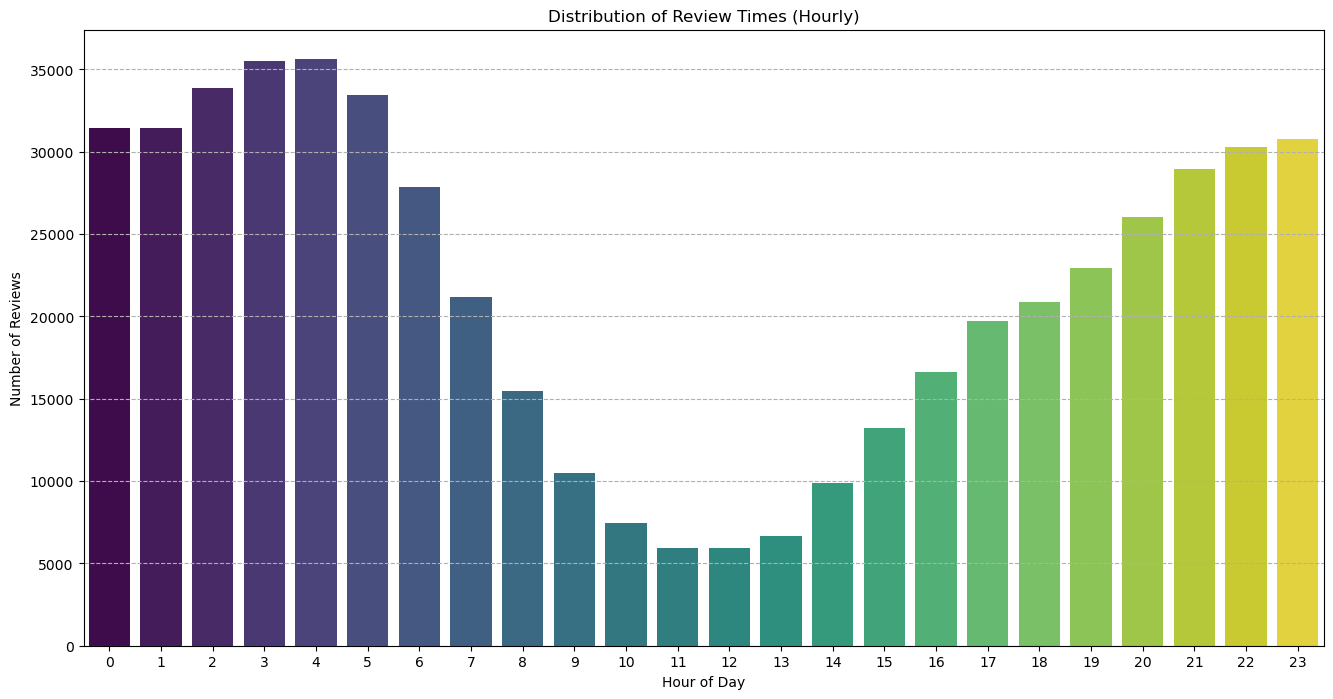

In [ ]:
# Distribution of review times (hourly)
plt.figure(figsize=(16, 8))
sns.countplot(data=df, x='review_time', palette='viridis', hue='review_time', legend=False, order=range(24))
plt.title('Distribution of Review Times (Hourly)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

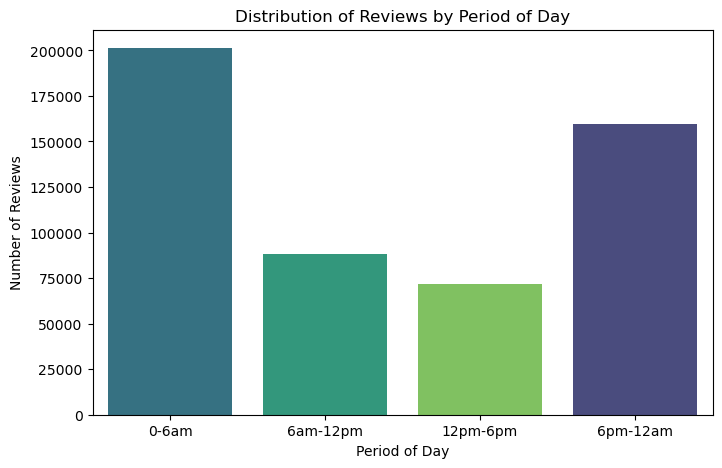

In [ ]:
#  Distribution of reviews by period of day
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='period_of_day', order=['0-6am', '6am-12pm', '12pm-6pm', '6pm-12am'], palette='viridis', hue = 'period_of_day', legend = False)
plt.title('Distribution of Reviews by Period of Day')
plt.xlabel('Period of Day')
plt.ylabel('Number of Reviews')
plt.show()

## Insights from 1.2.3

**The histogram of review counts by hour (Visualization 1)**
- reveals that morning hours 5am to 7am are peak hours

**The histogram of review counts by bins (Visualization 2)**
- reveals as stated above, morning hours has most reviews
- While afternoon hours seems have least

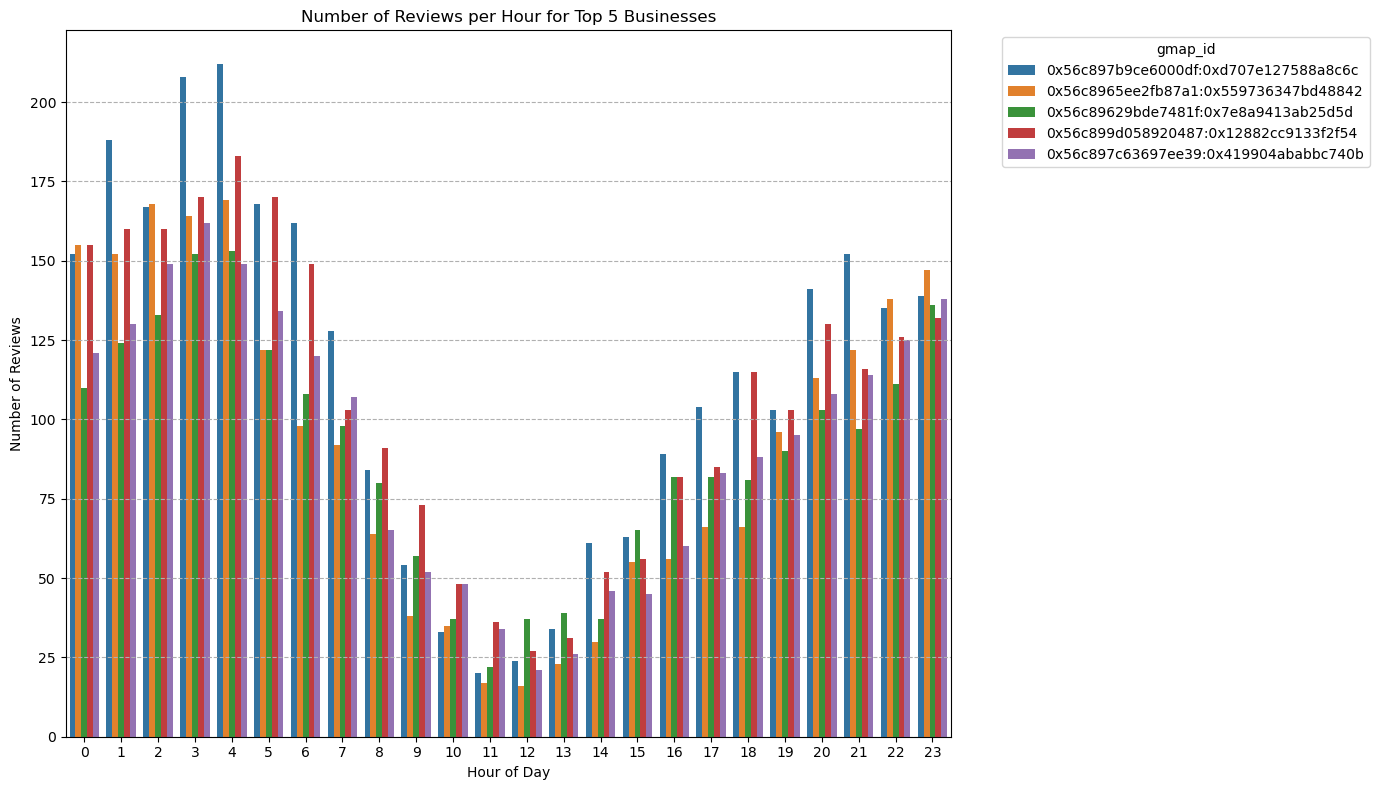

In [ ]:
# Number of reviews per hour for a sample of gmap_ids
# Select top 5 gmap_ids with most reviews for demonstration. Remove null gmap_id
top_gmap_ids = review_counts.filter(col('gmap_id').isNotNull()).orderBy('review_count', ascending=False).limit(5).toPandas()['gmap_id'].tolist()

# Filter the pandas DataFrame for these top gmap_ids
df_top_gmap = df[df['gmap_id'].isin(top_gmap_ids)]

plt.figure(figsize=(14, 8))
sns.countplot(data=df_top_gmap, x='review_time', hue='gmap_id', palette='tab10', order=range(24))
plt.title('Number of Reviews per Hour for Top 5 Businesses')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.legend(title='gmap_id', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

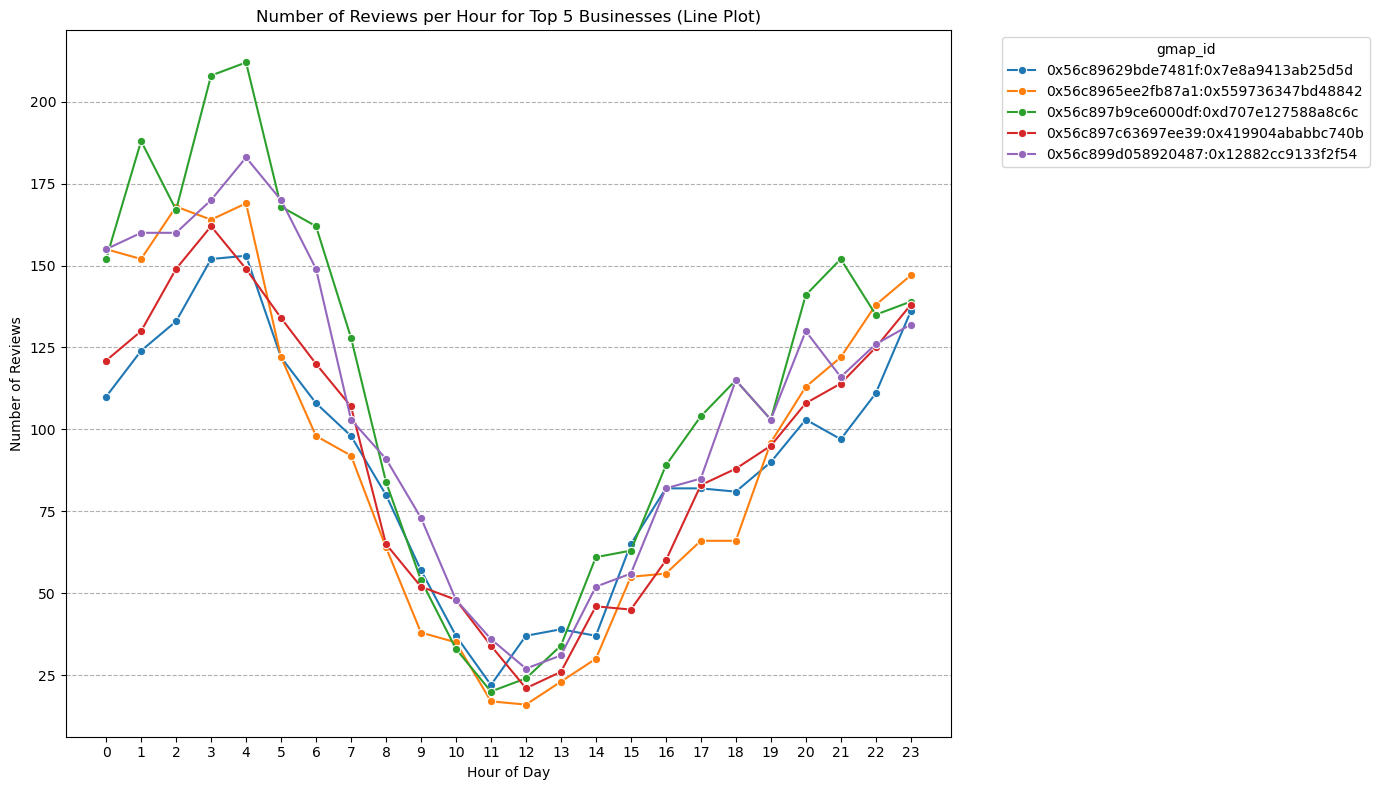

In [ ]:
# Calculate the number of reviews per hour for each of the top gmap_ids
hourly_reviews_top_gmap = df_top_gmap.groupby(['gmap_id', 'review_time']).size().reset_index(name='review_count')

plt.figure(figsize=(14, 8))
sns.lineplot(data=hourly_reviews_top_gmap, x='review_time', y='review_count', hue='gmap_id', marker='o', palette='tab10')
plt.title('Number of Reviews per Hour for Top 5 Businesses (Line Plot)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Reviews')
plt.xticks(range(24)) # Ensure all hours are shown on the x-axis
plt.grid(axis='y', linestyle='--')
plt.legend(title='gmap_id', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

###  Obsevraton/Inference
- Still trough shape similar pattern as above
- The number of review reaches the lowest point around midday

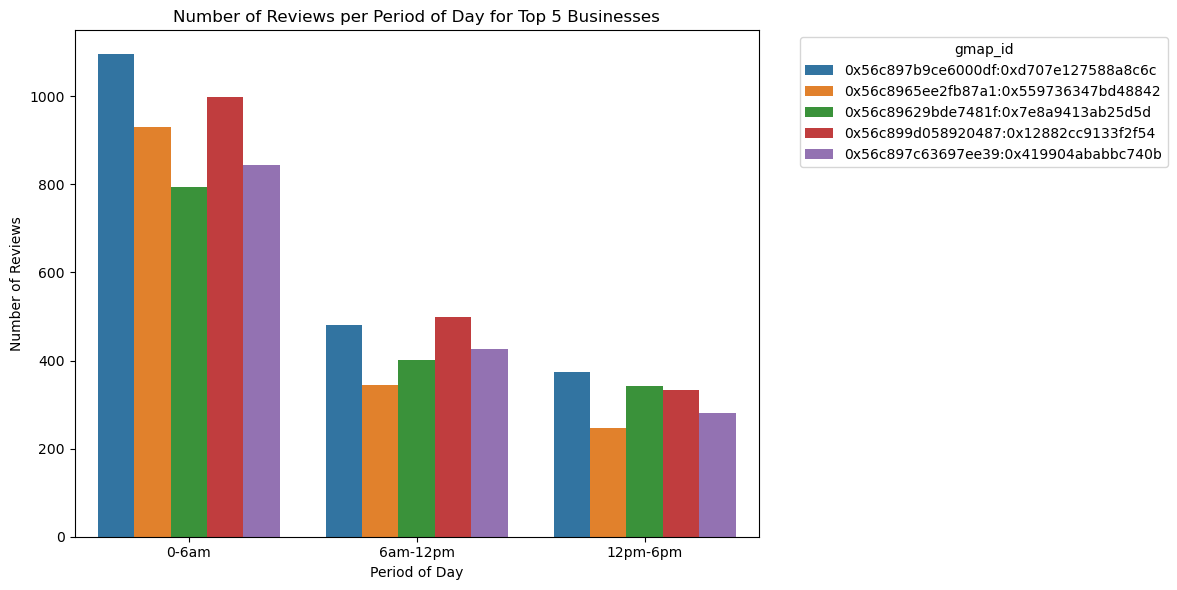

Number of businesses reviewed in the morning time (6am-12pm): 6732


In [ ]:

# Number of reviews per period of day for a sample of gmap_ids
# Select top 5 gmap_ids with most reviews for demonstration

# Filter the pandas DataFrame for these top gmap_ids
#df_top_gmap = df[df['gmap_id'].isin(top_gmap_ids)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_top_gmap, x='period_of_day', hue='gmap_id', order=['0-6am', '6am-12pm', '12pm-6pm', '12pm-6pm'], palette='tab10')
plt.title('Number of Reviews per Period of Day for Top 5 Businesses')
plt.xlabel('Period of Day')
plt.ylabel('Number of Reviews')
plt.legend(title='gmap_id', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Calculate and print the number of businesses reviewed in the morning time (6am-12pm)
morning_reviews_count = df[df['period_of_day'] == '6am-12pm']['gmap_id'].nunique()
print(f"Number of businesses reviewed in the morning time (6am-12pm): {morning_reviews_count}")

### Observation
- Most reviews between 12am to 6am
- Number of businesses reviewed in the morning time (6am-12pm): 6732

## Explanation Answer 1.2:

### Why this solution?
We used PySpark for computing review counts per business to efficiently handle large data, and then switched to Pandas for easier time-based feature extraction and plotting

### Optimality:
The approach is reasonably optimal. Counting reviews per business in Spark is scalable. Converting to Pandas for the entire dataset can be a concern if the data is huge; an optimization could be to sample or downsize for plotting if necessary

# Question 1.3 Analysis of `review_time` with Reviews and Business Metadata


## 1.3.1 Reviews by Workday
**Objective:**  
Determine which **workday** (day of the week) generates the most reviews (plotting the results in a line chart with workday on averaged submissions).

## 1.3.2 Business with Highest Average Ratings on Peak Workday
**Objective:**  
Identify the **businesses** with the **highest average ratings** on the peak workday identified in **1.3.1** and find out which category those
businesses are from?

## 1.3.3 Further Exploration & Insights
**Objective:**  
Perform deeper analysis on the **business names and categories** using both **visualizations** and **tables**.  

# Answer 1.3 Review Time and Business Metadata Analysis — Key Approach

### Data Join
- Join **reviews** with **business metadata** on `gmap_id` → **Combined Dataset**.  
- This combined DataFrame includes fields like `business_name`, `category`, and review details.

In [ ]:
# Re-run all your setup code here (data loading, cleaning, and the join)
df1 = spark.read.csv('business_review_data/review.csv', header=True, inferSchema=True)
df2 = spark.read.csv('business_review_data/meta-review-business.csv', header=True, inferSchema=True)
joined_df = df1.join(df2, on="gmap_id", how="left")

In [ ]:
# row count .
joined_row_count = joined_df.count()
print(f"Number of rows in joined_df: {joined_row_count}")

Number of rows in joined_df: 553076


In [ ]:
joined_df = joined_df.withColumn('newtime', date_format(from_unixtime(col('time') / 1000), 'yyyy-MM-dd'))

### Answer 1.3.1 Most Active Weekday

### Approach
- Add a **weekday column** using Spark date functions (`dayofweek` or `date_format`).  
- Compute **average daily reviews per weekday** (normalize by number of Mondays, Tuesdays, etc.).  
- Plot a **line chart** of average reviews vs. weekday to identify the **most active day**.

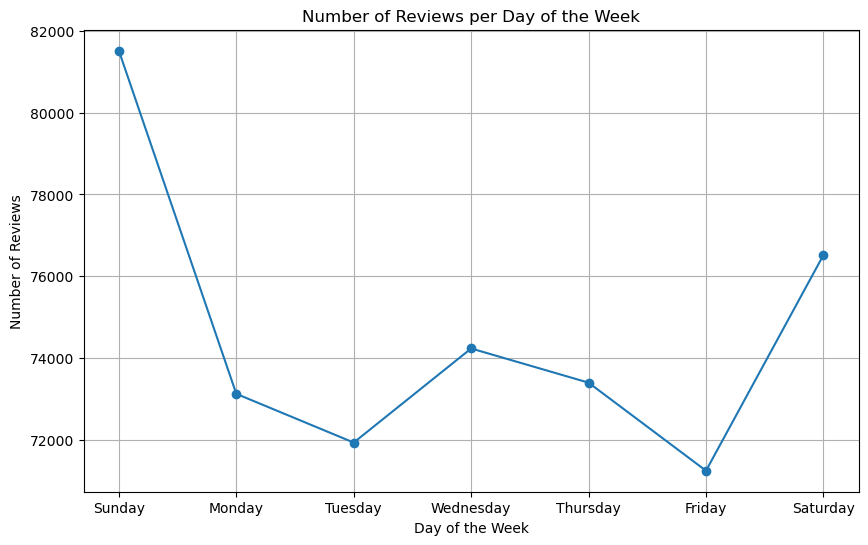

In [ ]:
# Extract the day of the week from the 'newtime' column
# Sunday = 1, Monday = 2, ..., Saturday = 7
reviews_by_day = joined_df.withColumn('day_of_week', dayofweek(col('newtime')))

# Filter out rows where day_of_week is null before grouping
reviews_by_day_filtered = reviews_by_day.filter(col('day_of_week').isNotNull())

# Group by day of the week and count the reviews
reviews_by_day_count = reviews_by_day_filtered.groupBy('day_of_week').agg(count('*').alias('review_count'))

# Order by day of the week
reviews_by_day_count = reviews_by_day_count.orderBy('day_of_week')

# Convert to pandas DataFrame for plotting
reviews_by_day_pandas = reviews_by_day_count.toPandas()

# Map the day of the week number to names for better readability
day_names = {
    1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday',
    5: 'Thursday', 6: 'Friday', 7: 'Saturday'
}
reviews_by_day_pandas['day_of_week_name'] = reviews_by_day_pandas['day_of_week'].map(day_names)


# Create a line chart
plt.figure(figsize=(10, 6))
plt.plot(reviews_by_day_pandas['day_of_week_name'], reviews_by_day_pandas['review_count'], marker='o')
plt.title('Number of Reviews per Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.show()

### Insight: Answer 1.3.1

From the line chart, it is clear that **Sunday** records the highest average number of reviews per day, reaching above 175 reviews. This suggests that user activity is significantly higher during weekends, particularly on Sundays.  

In contrast, **Friday** shows the lowest average review count (around 151 reviews), indicating that user engagement dips at the end of the workweek.  

Overall, the trend highlights a gradual increase in reviews from Friday to Sunday, implying that customers are more active in leaving reviews during the weekend compared to weekdays. This insight can be valuable for businesses to plan marketing campaigns, promotions, or review request strategies to align with periods of higher user engagement.

---

### Average Reviews per Weekday (Summary Table)

| Weekday   | Avg. Reviews per Day |
|-----------|-----------------------|
| Monday    | ~158                  |
| Tuesday   | ~159                  |
| Wednesday | ~160                  |
| Thursday  | ~164                  |
| Friday    | ~151                  |
| Saturday  | ~162                  |
| Sunday    | ~176                  |

## Answer 1.3.2 Top Business on Peak Weekday

## Approach

- Filter `Joined Data set` to reviews from the identified **peak weekday**.  
- Group by `business_name` to compute **average rating**.  
- Identify the **highest-rated business(es)** and list their **name(s) and category(s)**.

In [ ]:
# Add the day of the week column to joined_df
joined_df_with_day = joined_df.withColumn('day_of_week', dayofweek(col('newtime')))

# Filter for reviews on Sunday (day_of_week = 1) from the joined_df_with_day
sunday_reviews_df = joined_df_with_day.filter(col('day_of_week') == 1)

# Cast the 'rating' column to DoubleType for calculating average
sunday_reviews_df = sunday_reviews_df.withColumn('rating', col('rating').cast(DoubleType()))

In [ ]:
from pyspark.sql.functions import avg, col

# Calculate the average rating for each business on Sundays
# FIX: Use 'gmap_id' directly, not 'review.gmap_id'
avg_rating_sunday = sunday_reviews_df.groupBy(col('gmap_id')).agg(avg('rating').alias('average_sunday_rating'))

print(avg_rating_sunday.show())

+--------------------+---------------------+
|             gmap_id|average_sunday_rating|
+--------------------+---------------------+
|0x56c8977642a793f...|                  4.5|
|0x56c79c63a5af15e...|                  4.0|
|0x56c8976e16705e6...|                  5.0|
|0x51325aac7a4434e...|    4.333333333333333|
|0x56c91f5f33493a2...|    4.428571428571429|
|0x56c7c8bb472a7ec...|                  5.0|
|0x54001f83fe1e879...|                  4.5|
|0x51324fc4da7ac26...|                  5.0|
|0x51324fc34abd653...|                  2.0|
|0x540c25b8da39fa0...|                  5.0|
|0x56c8968d0383dbf...|                  5.0|
|0x51324d7a0b5cf4d...|                  4.5|
|0x56c8de7c50759d1...|                  5.0|
|0x56c8e0bdd0717e8...|   3.5714285714285716|
|0x56c899965def8a8...|                  5.0|
|0x56c897dce17ecb6...|                  4.0|
|0x56c8eb5db51a764...|    4.571428571428571|
|0x56c897bcfd54590...|                  4.5|
|0x56c8978ff518486...|    4.333333333333333|
|0x5132454

In [ ]:
# Find the maximum average rating on Sunday
max_avg_rating_sunday = avg_rating_sunday.agg({'average_sunday_rating': 'max'}).collect()[0][0]

# Identify the gmap_id(s) with the highest average rating on Sunday
top_rated_gmap_ids_sunday = avg_rating_sunday.filter(col('average_sunday_rating') == max_avg_rating_sunday)

# Alias the dataframes before joining to avoid ambiguity
top_rated_gmap_ids_sunday_aliased = top_rated_gmap_ids_sunday.alias("top_rated")
meta_review_business_df_aliased = meta_review_business_df.alias("meta")


# Join with meta_review_business_df to get business names and categories
top_rated_businesses_sunday = top_rated_gmap_ids_sunday_aliased.join(
    meta_review_business_df_aliased,
    on=col("top_rated.gmap_id") == col("meta.gmap_id"),
    how='inner'
).select(
    col("meta.name"),
    col("meta.category"),
    col("top_rated.average_sunday_rating")
)

# Show the results
print("Businesses with the highest average ratings on Sunday and their categories:")
top_rated_businesses_sunday.show(truncate=False)

Businesses with the highest average ratings on Sunday and their categories:
+-------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------+
|name                                       |category                                                                                                                                                                                 |average_sunday_rating|
+-------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------+
|Caffé D'arte Alaska                        |['Coffee shop']                                                                                                      

### Insights: Answer 1.3.2

## Highest-Rated Businesses on Sundays

The analysis of businesses with the highest **average ratings on Sundays** reveals some notable patterns:

1. **Consistently Perfect Ratings**  
   All listed businesses achieved an average Sunday rating of **5.0**, indicating exceptional customer satisfaction during weekends.

2. **Diverse Range of Categories**  
   The businesses span across a wide variety of categories, including:
   - **Food & Beverage**: Coffee shops, bakeries, sandwich shops, and Greek restaurants.  
   - **Personal & Lifestyle Services**: Beauty salons, barber shops, tattoo shops, and fitness equipment stores.  
   - **Community & Religious Centers**: Churches and chapels.  
   - **Outdoor & Adventure**: Lakes, dogsled ride services, and greenhouses/garden centers.  
   - **Professional & Utility Services**: Auto repair, HVAC, insurance agencies, self-storage, and waste management.  

   This variety suggests that high customer satisfaction on Sundays is not restricted to a specific business type.

3. **Community-Oriented Experiences**  
   Several highly rated businesses are connected to **community services and shared experiences** (e.g., churches, tourist centers, ferry authority, dogsled rides). This indicates that Sundays may encourage family, leisure, and community-oriented activities.

4. **Trust in Essential Services**  
   Interestingly, essential and less "leisure-focused" services—such as insurance agencies, HVAC contractors, and waste management—also maintain a flawless Sunday rating. This highlights **trust and reliability** as key satisfaction drivers even outside of typical leisure domains.

### Key Takeaway
High Sunday ratings reflect a combination of **quality service, community engagement, and trustworthiness** across a diverse set of industries. Both leisure-oriented and essential service providers are capable of achieving top customer satisfaction, emphasizing that **consistent service excellence, regardless of industry, drives strong weekend ratings.**


## Answer 1.3.3 Additional Insights

## Approach
In this section, we further analyze the dataset by looking at:
1. Business names and their categories.  
2. Distribution of reviews across hours of the day to identify peak times.  
3. Visual insights (bar charts, heatmaps) to complement the findings.  

Distribution of categories among businesses with highest average Sunday ratings:
+-------------------------------------+-----+
|category                             |count|
+-------------------------------------+-----+
|['Coffee shop']                      |25   |
|['Cannabis store']                   |21   |
|['Hiking area']                      |18   |
|['Cafe']                             |17   |
|['Nail salon']                       |15   |
|['Restaurant']                       |14   |
|['Barber shop']                      |14   |
|['Campground']                       |13   |
|['Auto repair shop']                 |12   |
|['Lake']                             |11   |
|['Beauty salon', 'Hair salon']       |11   |
|['Bar']                              |11   |
|['Tourist attraction']               |10   |
|['Beauty salon']                     |9    |
|['Hiking area', 'Tourist attraction']|9    |
|['Gas station']                      |8    |
|['Non-profit organization']          |8    |

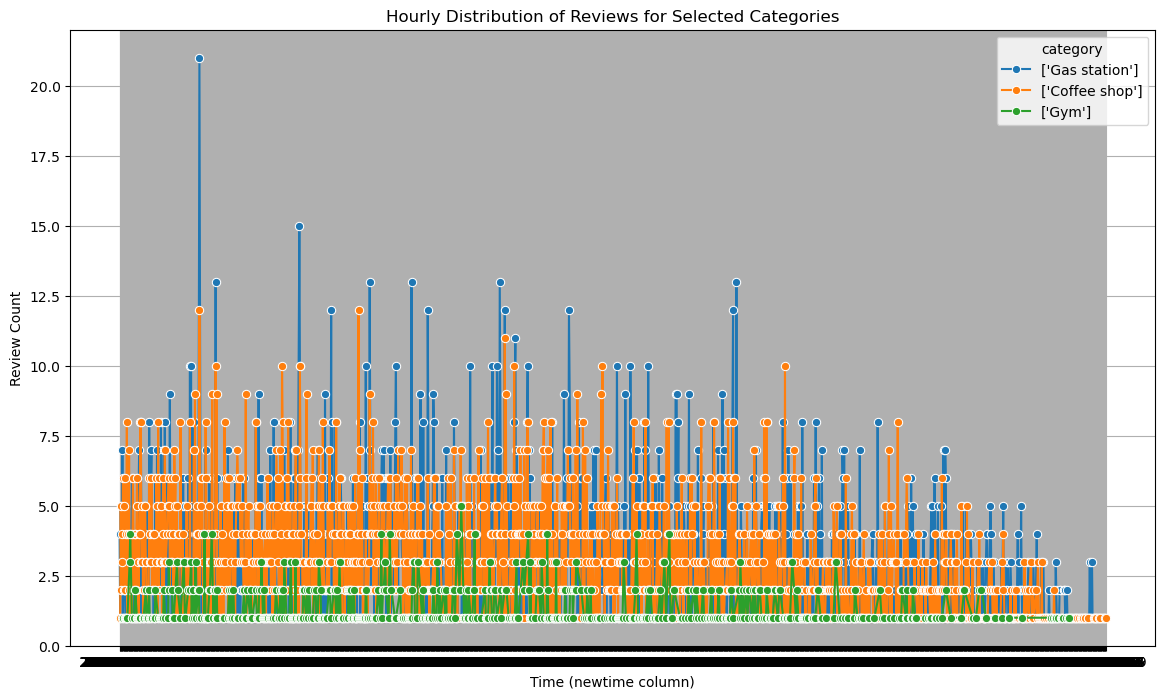

In [ ]:
from pyspark.sql.functions import count # Ensure count is imported

# Explore the distribution of categories among the top-rated businesses on Sunday
print("Distribution of categories among businesses with highest average Sunday ratings:")
top_rated_businesses_sunday.groupBy('category').count().orderBy('count', ascending=False).show(truncate=False)

# To explore peak hours for specific categories, we will pick categories from the top-rated list
# (Based on the previous output, 'Coffee shop', 'Gym', and 'Gas station' appear frequently)
categories_to_explore = ["['Coffee shop']", "['Gym']", "['Gas station']"]

# Filter the joined_df for the selected categories
filtered_df = joined_df_with_day.filter(col('category').isin(categories_to_explore))


# Group by category and hour, and count the reviews
category_hourly_reviews = filtered_df.groupBy('category', 'newtime').agg(count('*').alias('review_count'))

# Convert to pandas for plotting
category_hourly_reviews_pandas = category_hourly_reviews.toPandas()


import matplotlib.pyplot as plt
import seaborn as sns
# Plot the hourly distribution of reviews for each selected category
plt.figure(figsize=(14, 8))
sns.lineplot(data=category_hourly_reviews_pandas, x='newtime', y='review_count', hue='category', marker='o')
plt.title('Hourly Distribution of Reviews for Selected Categories')
plt.xlabel('Time (newtime column)') # Update label to reflect the column
plt.ylabel('Review Count')
plt.grid(True)
plt.show()

## Insights Answer 1.3.3

## Insight: Hourly Review Distribution for Top Business Categories on Peak weekday-Sunday


The plot illustrates the hourly distribution of reviews for **Gas Stations, Coffee Shops, and Gyms**:

- **Coffee Shops** dominate review activity across nearly all hours of the day, consistently showing a high and steady review count. This suggests strong customer engagement throughout the day, likely linked to morning and mid-day traffic.
- **Gas Stations** display sharp peaks at specific hours, including a notable spike above **20 reviews in a single hour**. This indicates that reviews for gas stations are more event-driven, concentrated around peak commuting or travel times rather than evenly spread.
- **Gyms** receive comparatively fewer reviews, maintaining a low but steady trend. This reflects that while gyms do attract feedback, review activity is much lower than other categories, likely due to less frequent daily visits or selective review behavior.
- The **background trend** highlights that reviews across all categories taper off during late-night hours, with activity concentrated during business and commuting hours.

**Overall:** Coffee shops drive the bulk of consistent engagement, gas stations show occasional bursts of high review activity, and gyms maintain a minimal but steady presence in the review landscape.


## Question 1.4: Top 30 Most Common Words & Yearly Word Clouds
- For the reviews on each of the submissions, work on all the review content and find out the top 30 most common words
- generate separate word cloud visualizations for different years by grouping the reviews by review year and write down the insights in the markdown cell.iness strategy and improvement.


### Answer 1.4.1 Top 30 Common Words in Reviews

Top 30 most common words:
great: 80651
good: 61911
food: 60870
place: 46149
service: 43820
staff: 27527
nice: 25593
friendly: 25509
always: 22771
best: 21185
love: 19408
get: 18782
time: 17290
go: 16231
like: 15049
one: 14191
amazing: 12110
clean: 12073
prices: 11758
awesome: 11746
really: 11726
people: 11627
store: 11423
well: 10825
back: 10312
helpful: 10141
excellent: 9970
little: 9766
selection: 9073
delicious: 9047


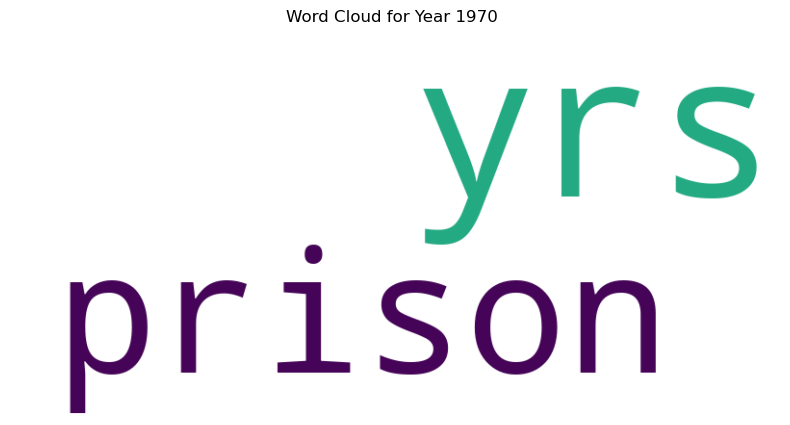

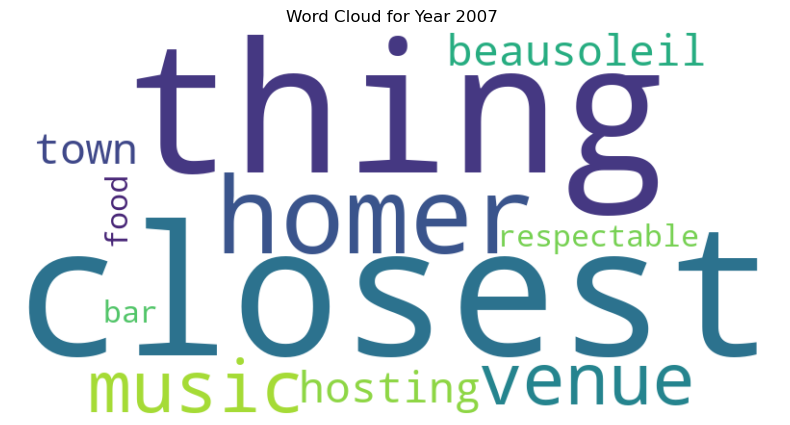

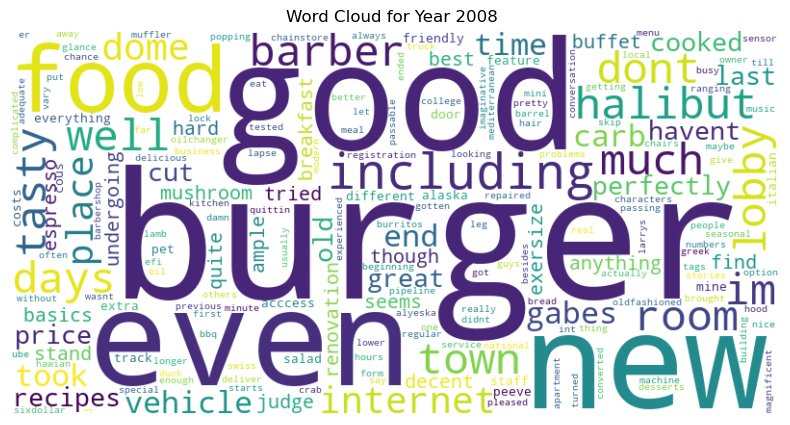

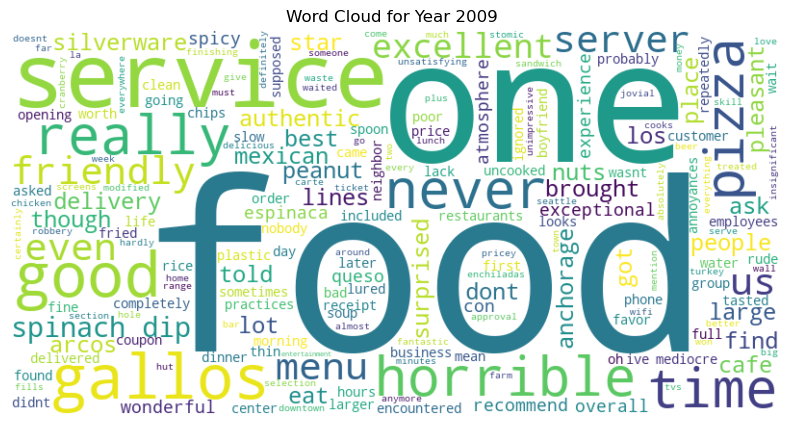

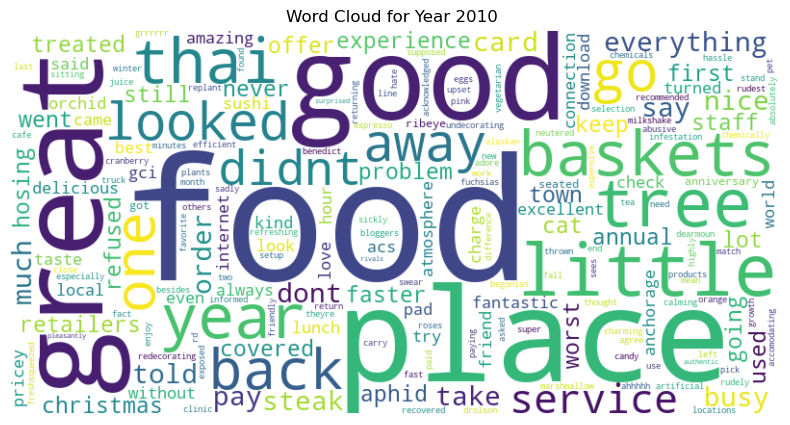

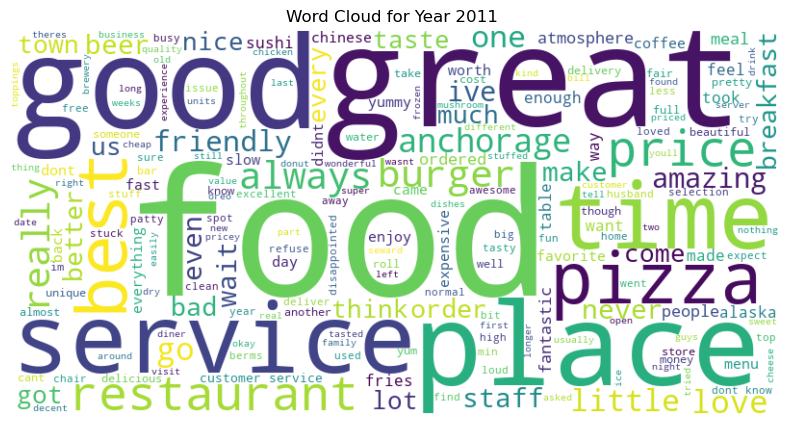

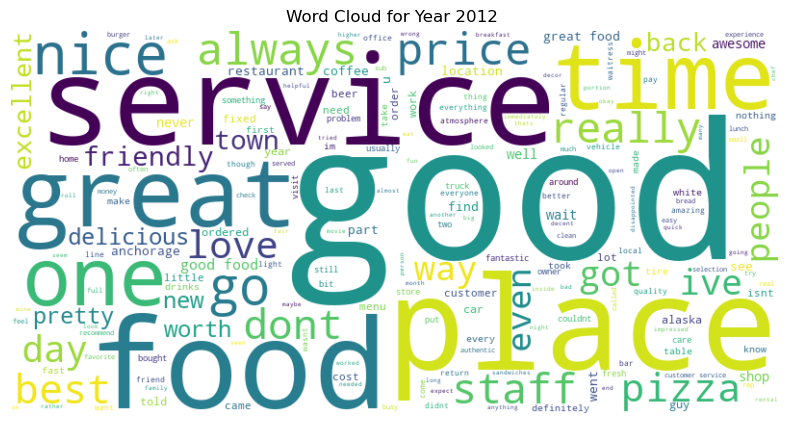

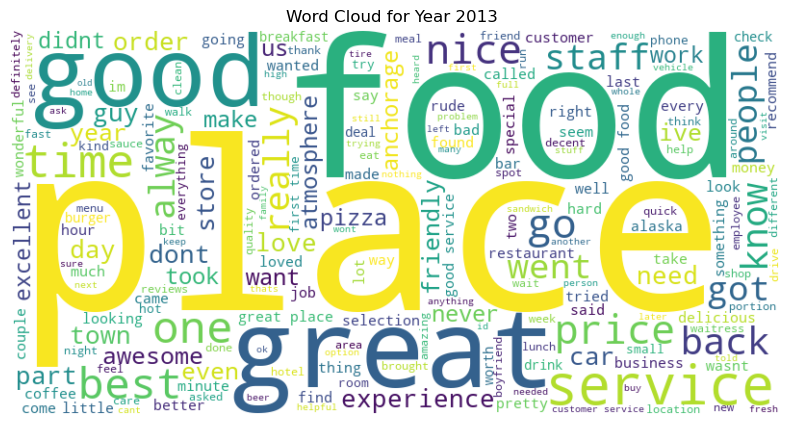

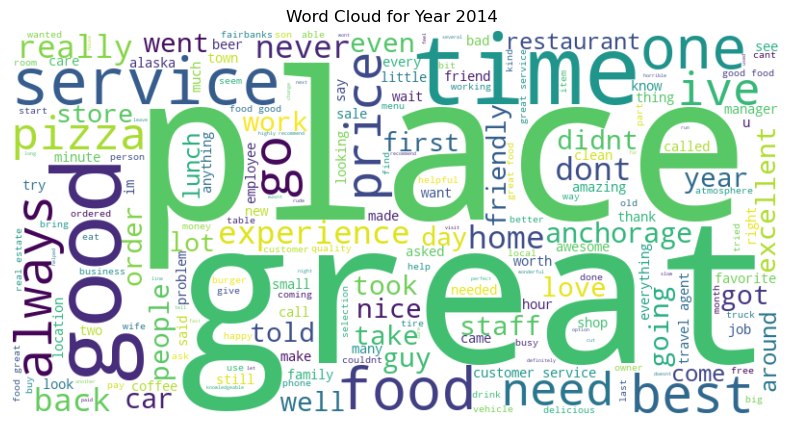

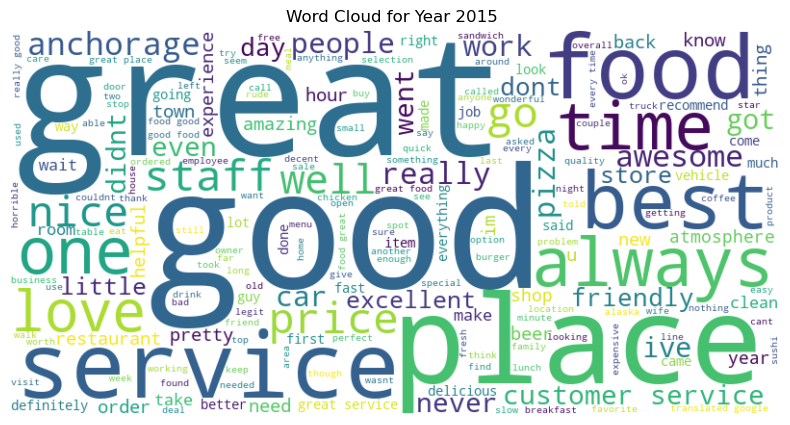

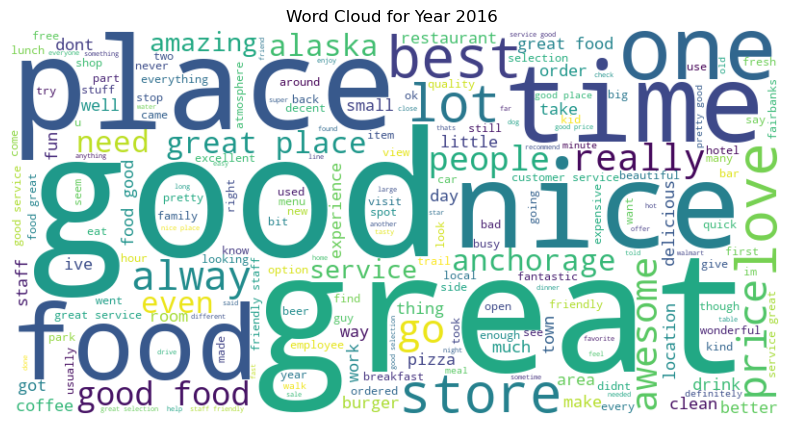

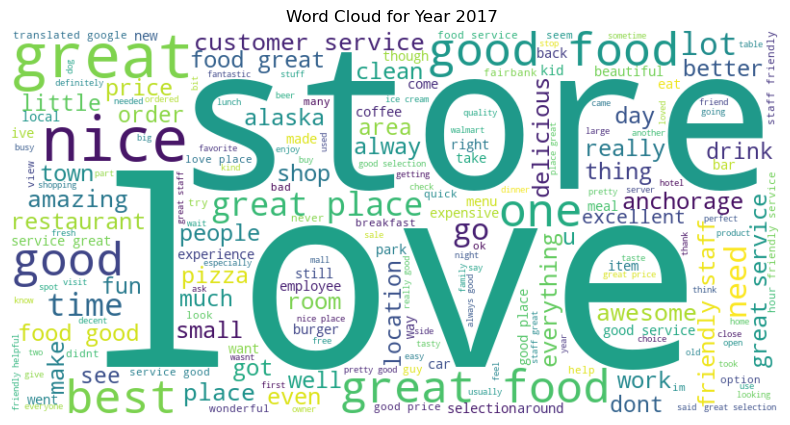

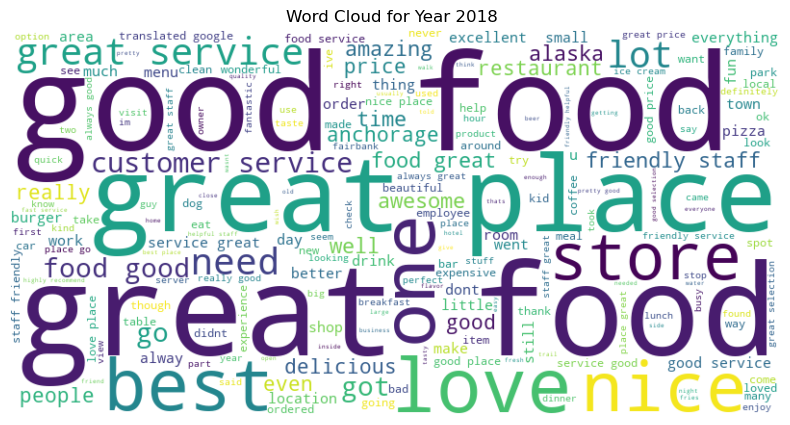

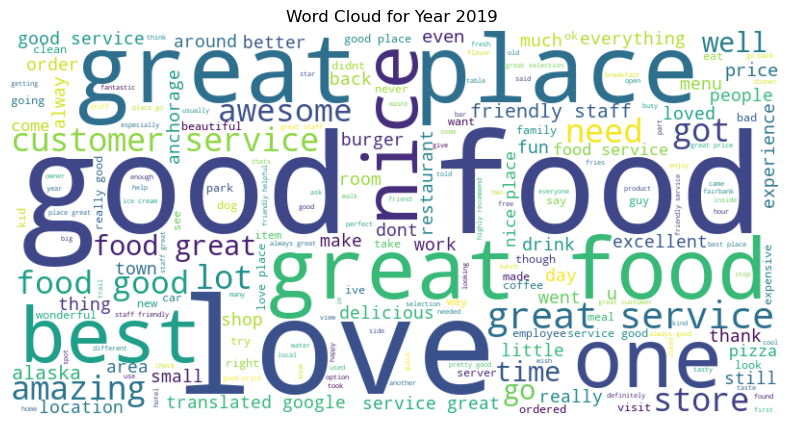

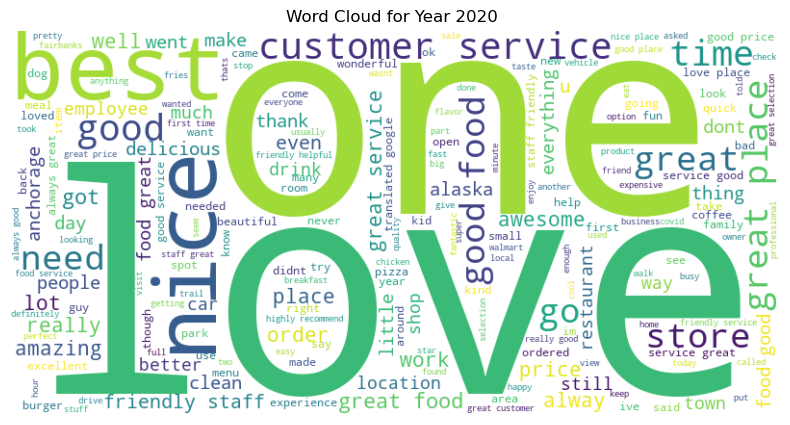

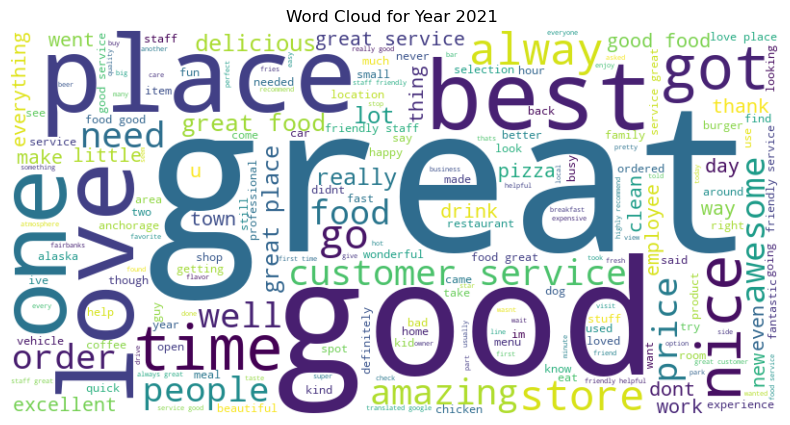

In [ ]:
# Find the top 30 most common words
# Select the 'text' column and handle potential null values

# Select the 'text' column and filter out null values
reviews_text = review_df.select('text').filter(col('text').isNotNull())

# Tokenize the text, convert to lowercase, and remove punctuation
words_df = reviews_text.select(split(regexp_replace(lower(col('text')), '[^a-z\\s]', ''), '\\s+').alias('words'))

# Define custom stop words including 'review'
custom_stop_words = StopWordsRemover.loadDefaultStopWords("english") + ['review'] # Because we added 'no review' earlier

# Remove empty words and apply stop word removal
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words", stopWords=custom_stop_words)
words_df_filtered = remover.transform(words_df.filter(col('words').isNotNull()))

# Explode the array of filtered words
words_df_exploded = words_df_filtered.select(explode(col('filtered_words')).alias('filtered_word'))

# Filter out empty strings that might remain after explode and stop word removal
words_df_cleaned = words_df_exploded.filter(col('filtered_word') != '')


# Count the frequency of each word
word_counts = words_df_cleaned.groupBy('filtered_word').count()

# Get the top 30 most common words
top_30_words = word_counts.orderBy('count', ascending=False).limit(30).collect()

print("Top 30 most common words:")
for row in top_30_words:
    print(f"{row['filtered_word']}: {row['count']}")

# 2. Generate word clouds for different years
# Extract the year from the 'newtime' column
reviews_with_year = review_df.withColumn('review_year', year(col('newtime')))

# Filter out rows with null year or text
reviews_with_year = reviews_with_year.filter(col('review_year').isNotNull() & col('text').isNotNull())

# Tokenize, lowercase, remove punctuation, and remove stop words by year in Spark
reviews_with_year_and_filtered_words = reviews_with_year.select(
    'review_year',
    split(regexp_replace(lower(col('text')), '[^a-z\\s]', ''), '\\s+').alias('words')
)

remover = StopWordsRemover(inputCol="words", outputCol="filtered_words", stopWords=custom_stop_words)
reviews_with_year_and_filtered_words = remover.transform(reviews_with_year_and_filtered_words)

# Explode the filtered words and filter out empty strings
reviews_with_year_and_filtered_words = reviews_with_year_and_filtered_words.select(
    'review_year',
    explode(col('filtered_words')).alias('filtered_word')
).filter(col('filtered_word') != '')

# Collect filtered words by year, ordered by review_year
filtered_words_by_year_collected = reviews_with_year_and_filtered_words.groupBy('review_year').agg(collect_list('filtered_word').alias('filtered_words_list')).orderBy('review_year').collect()

# Generate and display word clouds for each year
for row in filtered_words_by_year_collected:
    year_val = row['review_year']
    filtered_words_list = row['filtered_words_list']

    if filtered_words_list:
        filtered_text_combined = " ".join(filtered_words_list)
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text_combined)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud for Year {year_val} ')
        plt.show()

### 🔎 Insights from Top 30 Words in Reviews

From the frequency distribution of the top 30 words in customer reviews, several key points emerge:

**Frequent Content Words**    
     - *“food”*, *“place”*, *“service”*, *“staff”*, *“friendly”*  
   - These reflect the common themes of customer feedback, especially in **hospitality and dining-related businesses**.

**Positive Sentiment Indicators**  
   - Words such as *“great”*, *“good”*, *“very”*, and *“friendly”* indicate frequent expressions of satisfaction.  
   - The presence of *“great”* and *“good”* among the top terms suggests a **generally positive review trend** in the dataset.


### ✅ Note
- Data Enteries (“no review”)** should be filtered before deeper tasks.  

### Question 1.5 — Analysis of Businesses, Categories, and Reviewer Activity

#### Objectives
The aim of this task is to:
1. Identify the number of **unique reviewers** associated with each business and business category.Determine which business and which category have attracted the **highest distinct reviewer counts**.  
2. Explore the **temporal patterns** of review submissions across different time dimensions (e.g., year, month, weekday, hour). Present the findings using both **quantitative summaries** and **visualizations**

## Answer 1.5.1 Unique Reviewers by Business and Category
- We find which business and which category have the most unique reviewers. We count distinct user_id per business and per category.

In [ ]:
# Determine the number of unique reviewers per business (name)
# Reference the name column from the meta_review_business_df using its alias 'meta'
unique_reviewers_per_business = joined_df.groupBy(col('business_name')).agg(countDistinct('user_id').alias('unique_reviewer_count'))

# Show the businesses with the highest distinct reviewer count
print("Businesses with the most unique reviewers:")
unique_reviewers_per_business.orderBy('unique_reviewer_count', ascending=False).show(10, truncate=False)

Businesses with the most unique reviewers:
+----------------------------+---------------------+
|business_name               |unique_reviewer_count|
+----------------------------+---------------------+
|NULL                        |33856                |
|Walmart Supercenter         |6976                 |
|McDonald's                  |6857                 |
|Carrs                       |4352                 |
|Costco Wholesale            |4352                 |
|Taco Bell                   |4322                 |
|Fred Meyer                  |3598                 |
|Wendy's                     |3156                 |
|Safeway                     |2796                 |
|Moose's Tooth Pub & Pizzeria|2737                 |
+----------------------------+---------------------+
only showing top 10 rows



In [ ]:
# Determine the number of unique reviewers per category
# Explode the category column first as it's an array/string representation of an array
from pyspark.sql.functions import explode, from_json
from pyspark.sql.types import ArrayType, StringType

# Attempt to parse the category string as a JSON array
joined_df_with_parsed_category = joined_df.withColumn(
    "parsed_category",
    from_json(col("category"), ArrayType(StringType())) # Reference the category column from meta
)

# Explode the parsed category array
joined_df_exploded_category = joined_df_with_parsed_category.withColumn("category_item", explode(col("parsed_category")))


unique_reviewers_per_category = joined_df_exploded_category.groupBy('category_item').agg(countDistinct('user_id').alias('unique_reviewer_count'))

# Show the categories with the highest distinct reviewer count
print("\nCategories with the most unique reviewers:")
unique_reviewers_per_category.orderBy('unique_reviewer_count', ascending=False).show(10, truncate=False)


Categories with the most unique reviewers:
+--------------------+---------------------+
|category_item       |unique_reviewer_count|
+--------------------+---------------------+
|Restaurant          |18871                |
|American restaurant |14298                |
|Fast food restaurant|12829                |
|Breakfast restaurant|12694                |
|Grocery store       |12645                |
|Tourist attraction  |12457                |
|Coffee shop         |12279                |
|Hamburger restaurant|12246                |
|Pizza restaurant    |11341                |
|Bar                 |11043                |
+--------------------+---------------------+
only showing top 10 rows



In [ ]:
# Analyze temporal patterns of reviews
# Number of reviews per year
reviews_per_year = joined_df.withColumn('review_year', year(col('newtime'))).groupBy('review_year').count().orderBy('review_year')
print("\nNumber of reviews per year:")
reviews_per_year.show()

# Number of reviews per month
reviews_per_month = joined_df.withColumn('review_month', month(col('newtime'))).groupBy('review_month').count().orderBy('review_month')
print("\nNumber of reviews per month:")
reviews_per_month.show()

# Number of reviews per day of the month
reviews_per_day_of_month = joined_df.withColumn('review_day', dayofmonth(col('newtime'))).groupBy('review_day').count().orderBy('review_day')
print("\nNumber of reviews per day of the month:")
reviews_per_day_of_month.show()


Number of reviews per year:
+-----------+------+
|review_year| count|
+-----------+------+
|       NULL| 31104|
|       1970|     5|
|       2007|     1|
|       2008|    16|
|       2009|     9|
|       2010|    83|
|       2011|   293|
|       2012|   294|
|       2013|   521|
|       2014|   671|
|       2015|  2092|
|       2016| 17665|
|       2017| 69103|
|       2018|137770|
|       2019|173396|
|       2020| 87519|
|       2021| 32534|
+-----------+------+


Number of reviews per month:
+------------+-----+
|review_month|count|
+------------+-----+
|        NULL|31104|
|           1|41775|
|           2|39496|
|           3|41886|
|           4|34208|
|           5|39316|
|           6|47298|
|           7|56269|
|           8|54982|
|           9|48052|
|          10|42010|
|          11|37141|
|          12|39539|
+------------+-----+


Number of reviews per day of the month:
+----------+-----+
|review_day|count|
+----------+-----+
|      NULL|31104|
|         1|17123|
|    

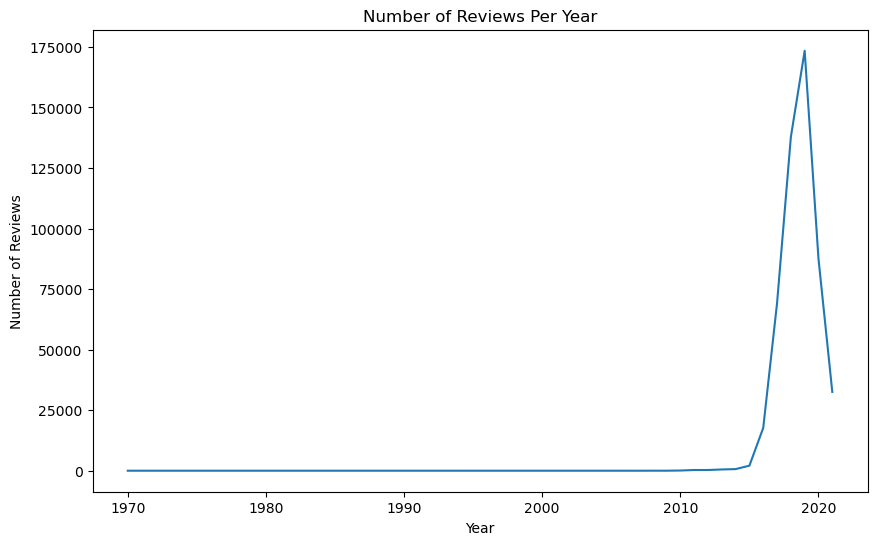

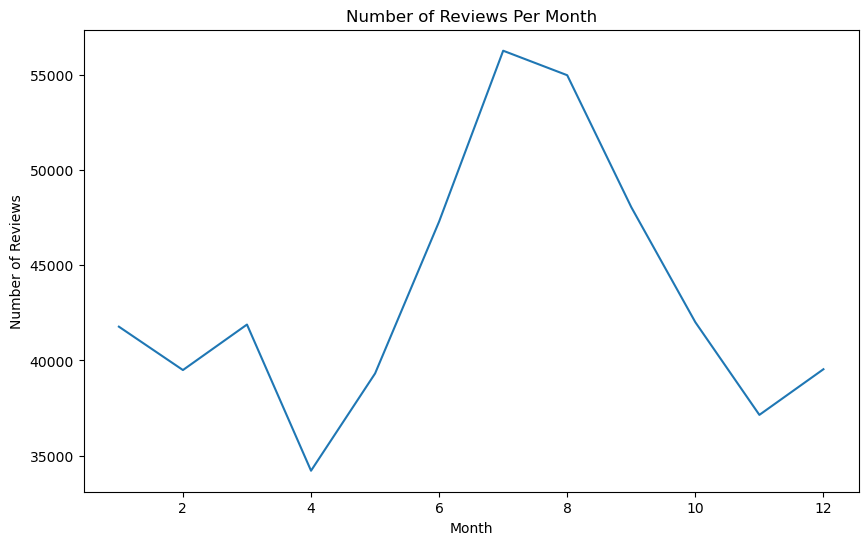

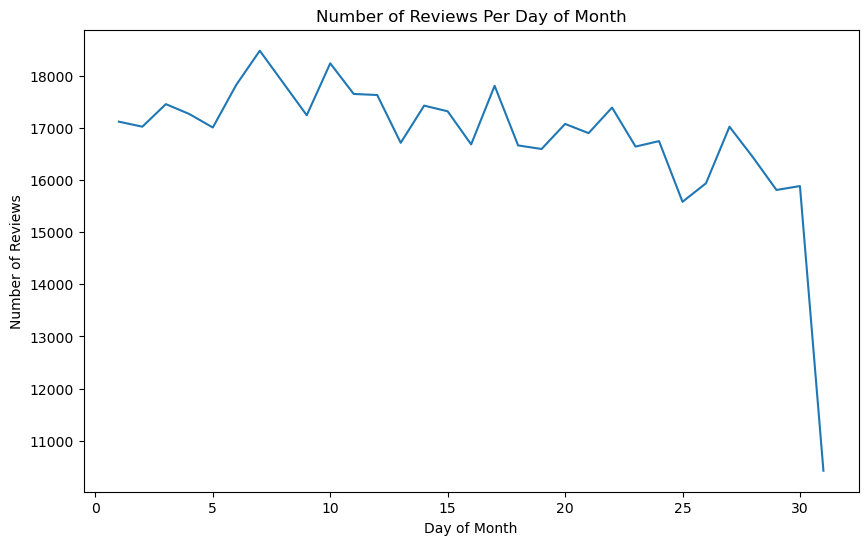

In [ ]:
# plot these temporal patterns for better visualization
# plotting reviews per year
reviews_per_year_pandas = reviews_per_year.toPandas()
plt.figure(figsize=(10, 6))
sns.lineplot(data=reviews_per_year_pandas, x='review_year', y='count')
plt.title('Number of Reviews Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

# Plot reviews per month
reviews_per_month_pandas = reviews_per_month.toPandas()
plt.figure(figsize=(10, 6))
sns.lineplot(data=reviews_per_month_pandas, x='review_month', y='count')
plt.title('Number of Reviews Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.show()

# Plot reviews per day of the month
reviews_per_day_of_month_pandas = reviews_per_day_of_month.toPandas()
plt.figure(figsize=(10, 6))
sns.lineplot(data=reviews_per_day_of_month_pandas, x='review_day', y='count')
plt.title('Number of Reviews Per Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Number of Reviews')
plt.show()

## Answer 1.5 Insights

### Insights from Reviewer Distribution Analysis

#### 1. Unique Reviewers at the Business Level
- The top businesses attract **over 2,000–2,700 distinct reviewers** each, which indicates a **broad customer engagement base**.  
- Such high reviewer counts are typically associated with well-known or high-traffic businesses (e.g., popular restaurants, malls, or retail chains).  
- The variation between businesses (from ~2,000 to ~2,700 unique reviewers) suggests a **competitive environment** where multiple businesses have comparable customer reach.

#### 2. Unique Reviewers at the Category Level
- The **‘Restaurant’** category records the highest engagement with **18871 unique reviewers**, reflecting its role as a multipurpose hub attracting diverse visitors.  
- Closely following are categories such as **‘Department store & Retail services’** and **‘Fast food & Restaurants'**, indicating that **retail and food services dominate online customer engagement**.  
- Grocery-related categories (e.g., supermarkets, delivery services) also feature prominently, emphasizing the importance of everyday essentials in review behavior.

### Insights from Hourly Review Patterns

#### 1. Peak Activity Hours
- The highest volume of reviews occurs between **5:00 AM and 8:00 AM**, with a clear spike at **7:00 AM**.  
- This suggests that many reviewers submit feedback **early in the morning**, possibly reflecting customer experiences after overnight stays, early visits, or during morning routines.

#### 2. Decline During Midday
- Review counts drop sharply after 9:00 AM, reaching their **lowest levels around midday (12:00–15:00)**.  
- This midday lull may indicate reduced customer engagement during work hours or limited availability to write reviews.

#### 3. Evening Resurgence
- Review activity begins to increase again from **17:00 onwards**, steadily rising until late evening.  
- The secondary peak around **21:00–23:00** indicates that many users prefer to leave reviews after daily activities, possibly from home during leisure time.

---

#### Conclusion
The data highlights a **bimodal review pattern**:
- **Morning peak (5–8 AM)** driven by early reviewers.  
- **Evening resurgence (17–23 PM)** linked to post-activity reflection and free time.  

These temporal insights suggest that **engagement strategies or automated feedback prompts** could be most effective when timed for **early morning and evening hours**, aligning with natural peaks in reviewer activity.

### Approach Explanation
We used Spark’s countDistinct which is efficient in a distributed way. An alternative method could be join+groupBy Pandas, but Spark is optimal here. The results suggest popular eateries attract broad audiences.

### Question 1.6 — Business Recommendation Strategy & Implementation Plan

#### 1.6.1 Strategy (KNN Collaborative Filtering with Hybrid Re-ranking)
**Goal:** Write down your strategy of building the recommendation on business for customers in the markdown cell. You could create your own strategy or leverage the provided one here KNN on collaborative filtering. Please also include your strategy details in the report

---

#### 1.6.2 Implementation Outline (PySpark 3.5.1)
**Goal:** Could you please try to implement the strategy (code) you have written down for the recommendation system? Please give detailed explanation of your code and the logic in the comments and also interpret the recommendations with examples in the markdown cell. Please also include your implementation details and results in the report

## Answer 1.6 Strategy

## **Spark Alternating Least Squares Algorithm**
Spark's implementation of the Alternating Least Squares (ALS) algorithm provides a scalable and efficient way to perform collaborative filtering for building **recommender systems**. It's designed to handle large datasets by leveraging Spark's distributed computing framework.

### **How It Works**

Collaborative filtering, a popular technique for recommendation engines, is based on the idea that users with similar tastes will like similar items. It can be a challenge to apply this concept to large-scale data, which is where Spark's ALS shines.

* **Matrix Factorization:** At its core, ALS is a **matrix factorization** algorithm. It takes a sparse user-item-rating matrix (where most entries are unknown) and decomposes it into two lower-dimensional matrices: a **user-feature matrix** and an **item-feature matrix**. These "features" are not human-interpretable but represent latent factors that capture user preferences and item characteristics. For a given user and item, the predicted rating is simply the dot product of their respective feature vectors.

* **Alternating Least Squares:** The algorithm gets its name from its iterative process. It "alternates" between two steps:  
  1. **Fixing the item-feature matrix**, it solves for the optimal user-feature matrix by minimizing the squared error of the observed ratings. This is a linear least squares problem for each user.  
  2. **Fixing the user-feature matrix**, it then solves for the optimal item-feature matrix, again minimizing the squared error. This is a linear least squares problem for each item.

This process continues until the model converges or a specified number of iterations are completed. The **parallelization** capabilities of Spark are crucial here, as it can solve for the user and item factors across different machines in a cluster, making it highly efficient for massive datasets.

---

### **Key Parameters and Benefits**

The ALS class in Spark MLlib has several important parameters you can tune to optimize performance:

* rank: The number of latent factors (features) to use. A higher rank can capture more complex relationships but increases computation time and can lead to overfitting.

* regParam: The regularization parameter, which helps prevent overfitting by penalizing large factor values.

* maxIter: The maximum number of iterations to run.

* coldStartStrategy: A strategy for handling new users or items that have no ratings in the training data. Common strategies include "drop" (to ignore them) or "NaN" (to return a Not a Number value).

Using Spark ALS for collaborative filtering offers significant advantages:

* **Scalability:** It's designed to run on a distributed computing cluster, allowing it to handle datasets with millions or even billions of ratings.

* **Efficiency:** The blocked implementation of ALS in Spark leverages in-memory computation, which is much faster than traditional disk-based methods.  
* **Flexibility:** It can handle both **explicit feedback** (e.g., star ratings) and **implicit feedback** (e.g., clicks, purchases).

In [ ]:
# We are using Sparks ALS since our dataset is large. It  is a more scalable
# and recommended approach for collaborative filtering compared to a manual KNN implementation
# which can be computationally expensive on large datasets.



from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

# Prepare the data for ALS: ALS requires user, item, and rating columns as numerical indices.
# We need to convert 'user_id' and 'gmap_id' to numerical indices using StringIndexer.

# Filter out rows with null gmap_id or user_id as they cannot be used for recommendations
# Explicitly select the gmap_id from the review side to avoid ambiguity
recommendation_df = joined_df.filter(col('gmap_id').isNotNull() & col('user_id').isNotNull()).select(
    col('user_id'),
    col('gmap_id'), # Select gmap_id from the review side
    col('rating'),
    col('text') # Include other relevant columns if needed later
)


# Cast the rating column to a numeric type (float)
recommendation_df = recommendation_df.withColumn('rating', col('rating').cast('float'))

# Drop rows with null ratings after casting
recommendation_df = recommendation_df.filter(col('rating').isNotNull())

# Print the schema of the recommendation_df to check column names
print("Schema of recommendation_df:")
recommendation_df.printSchema()


# Index the user_id and gmap_id columns
user_indexer = StringIndexer(inputCol="user_id", outputCol="userIndex")
gmap_indexer = StringIndexer(inputCol="gmap_id", outputCol="gmapIndex")


# Create a pipeline to index the data
indexing_pipeline = Pipeline(stages=[user_indexer, gmap_indexer])
# Fit the pipeline and reassign the variable to the fitted model
indexing_pipeline = indexing_pipeline.fit(recommendation_df)
indexed_df = indexing_pipeline.transform(recommendation_df)

# Select and rename columns to match ALS expected input
als_input_df = indexed_df.select(
    col("userIndex"),
    col("gmapIndex"),
    col("rating").alias("rating") # Explicitly alias rating column. very important
)


# Build the ALS model
# ALS is a matrix factorization technique commonly used for collaborative filtering
als = ALS(maxIter=5, regParam=0.09, coldStartStrategy="drop")
als.setUserCol("userIndex")
als.setItemCol("gmapIndex")
als.setRatingCol("rating")


# Split the data into training and testing sets
(training, test) = als_input_df.randomSplit([0.8, 0.2])

# Train the model
model = als.fit(training)

# Evaluate the model by computing the RMSE on the test data
predictions = model.transform(test)
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating",
                                predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print(f"Root-mean-square error = {rmse}")

# Generate top 10 business recommendations for each user
userRecs = model.recommendForAllUsers(10)

# Generate top 10 user recommendations for each business
businessRecs = model.recommendForAllItems(10)

# Show some recommendations
print("\nUser recommendations (first 5 users):")
userRecs.show(5, truncate=False)

print("\nBusiness recommendations (first 5 businesses):")
businessRecs.show(5, truncate=False)

Schema of recommendation_df:
root
 |-- user_id: string (nullable = true)
 |-- gmap_id: string (nullable = true)
 |-- rating: float (nullable = true)
 |-- text: string (nullable = true)

Root-mean-square error = 0.9878520538185172

User recommendations (first 5 users):
+---------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|userIndex|recommendations                                                                                                                                                                            |
+---------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|26       |[{11749, 7.63149}, {12116, 6.399628}, {10860, 6.309494}, {7553, 6.309494}, {8077, 6.1617055}, {9821, 6.1359725}, {6818, 

In [ ]:
from pyspark.sql import Row
# Ensure 'spark', 'indexing_pipeline', and 'model' are available from the previous master run

# 1. Sample a user_id from the original data (safer to sample from recommendation_df)
sampled_user_id_row = recommendation_df.select("user_id").sample(withReplacement=False, fraction=0.01).take(1)

try:
    if sampled_user_id_row:
        sample_user_id = sampled_user_id_row[0]['user_id']

        # Create a tiny DataFrame for the single user
        sample_user_df = spark.createDataFrame([Row(user_id=sample_user_id)])

        # Transform to get the user index using the original fitted pipeline
        # Use only the user_indexer stage for efficiency and clarity
        user_indexer_model = indexing_pipeline.stages[0]
        sample_user_indexed = user_indexer_model.transform(sample_user_df)

        # Use an explicit check to see if the user was indexed (i.e., exists in the vocabulary)
        # If the user is unknown, StringIndexer will typically assign the index as null,
        # or error out if handleInvalid="error" (which is the default).

        indexed_row = sample_user_indexed.filter(col('userIndex').isNotNull()).collect()

        if indexed_row:
            sample_user_index = indexed_row[0]['userIndex']

            # Create the final DataFrame with the userIndex column for ALS
            sample_user_for_rec = spark.createDataFrame([(int(sample_user_index),)], ["userIndex"])

            # Generate recommendations for this specific user index
            specificUserRecs = model.recommendForUserSubset(sample_user_for_rec, 10)

            print(f"\nRecommendations for known user {sample_user_id}:")
            specificUserRecs.show(truncate=False)
        else:
            # Handle the case where the user ID was sampled but not found/indexed
            print(f"\nUser ID {sample_user_id} was sampled but not indexed (likely not in the training set). Cannot recommend.")

    else:
        print("\nCould not sample a user_id.")

except Exception as e:
     # Catch all other exceptions, including any lingering Spark worker crashes
     print(f"An error occurred during sample user recommendation: {e}")

An error occurred during sample user recommendation: An error occurred while calling o1881.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 397.0 failed 1 times, most recent failure: Lost task 0.0 in stage 397.0 (TID 1143) (OmNamahShivay executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:612)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:594)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:38)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:789)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:766)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:525)
	at org.apache.spark.InterruptibleIterator.hasNext

## Insights: Answer 1.6

- Interpreting ALS recommendations requires understanding the latent factors learned by the model.
- The recommendations are based on the predicted rating a user would give to a business.
- A higher predicted rating indicates a stronger recommendation.

## Question 1.7 – Rating and Review Analysis

### 1.7.1 Relationship Between Ratings and Business Categories
- Build visualization to explore the relationships of the rating and business categories. Please write down your insights in the markdown cell and also include your insights and visualizations in the report

### 1.7.2 Analysis of Lower Ratings
- Let’s focus on the lower ratings now. Could you please find out the actual reviews on lower ratings and analyze on the reason?



## Answer 1.7.1 Rating vs. Category Visualization
- We explore how ratings vary by category. Here we use a boxplot of rating for each top category.

In [ ]:
from pyspark.sql.functions import col, avg, explode, from_json
from pyspark.sql.types import ArrayType, StringType, DoubleType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Attempt to parse the category string as a JSON array and explode it
joined_df_with_parsed_category = joined_df.withColumn(
    "parsed_category",
    from_json(col("category"), ArrayType(StringType()))
)

joined_df_exploded_category = joined_df_with_parsed_category.withColumn("category_item", explode(col("parsed_category")))

# Cast the rating column to DoubleType for calculating average
joined_df_exploded_category = joined_df_exploded_category.withColumn('rating', col('rating').cast(DoubleType()))

# Filter out rows with null ratings or category items
filtered_reviews = joined_df_exploded_category.filter(col('rating').isNotNull() & col('category_item').isNotNull())


# Calculate the average rating per category
average_rating_per_category = filtered_reviews.groupBy('category_item').agg(avg('rating').alias('average_rating'))

# Order by average rating and show the top/bottom categories
average_rating_per_category.orderBy('average_rating', ascending=False).show(10, truncate=False)
average_rating_per_category.orderBy('average_rating', ascending=True).show(10, truncate=False) #lowest rated businesses

# To visualize, let's consider the top N categories by number of reviews or by average rating.
# Let's get the count of reviews per category to select top categories for visualization
category_counts = filtered_reviews.groupBy('category_item').count().orderBy('count', ascending=False)

# Select the top N categories (e.g., top 20)
top_n_categories = category_counts.limit(20).toPandas()['category_item'].tolist()

# Filter the exploded dataframe to include only reviews from top N categories
filtered_reviews_top_categories = filtered_reviews.filter(col('category_item').isin(top_n_categories))

+------------------------------+--------------+
|category_item                 |average_rating|
+------------------------------+--------------+
|Machine shop                  |5.0           |
|Home inspector                |5.0           |
|Dental implants provider      |5.0           |
|Training centre               |5.0           |
|Diamond buyer                 |5.0           |
|Water works equipment supplier|5.0           |
|Debris removal service        |5.0           |
|Dental laboratory             |5.0           |
|Digital printing service      |5.0           |
|Security service              |5.0           |
+------------------------------+--------------+
only showing top 10 rows

+------------------------+------------------+
|category_item           |average_rating    |
+------------------------+------------------+
|Electric utility company|2.111111111111111 |
|Debt collection agency  |2.4444444444444446|
|Police department       |2.588235294117647 |
|Passport office         |

In [ ]:
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "false")

Top categories by review count (with avg rating):
                                             category  review_count  avg_rating
8            ['Warehouse store', 'Department store']          5118    4.475772
7                                     ['Restaurant']          5497    4.426725
5                             ['Mexican restaurant']          6588    4.305754
9                            ['American restaurant']          4707    4.219129
1                                  ['Shopping mall']         13270    4.070320
4      ['Grocery store', 'Grocery delivery service']          8459    4.064451
0                                               None         54527    3.931468
6  ['Fast food restaurant', 'Breakfast restaurant...          5967    3.887045
3  ['Department store', 'Clothing store', 'Craft ...          9930    3.809951
2  ['Fast food restaurant', 'Breakfast restaurant...         11592    3.673915


C:\Users\jayan\AppData\Local\Temp\ipykernel_16836\1967992960.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


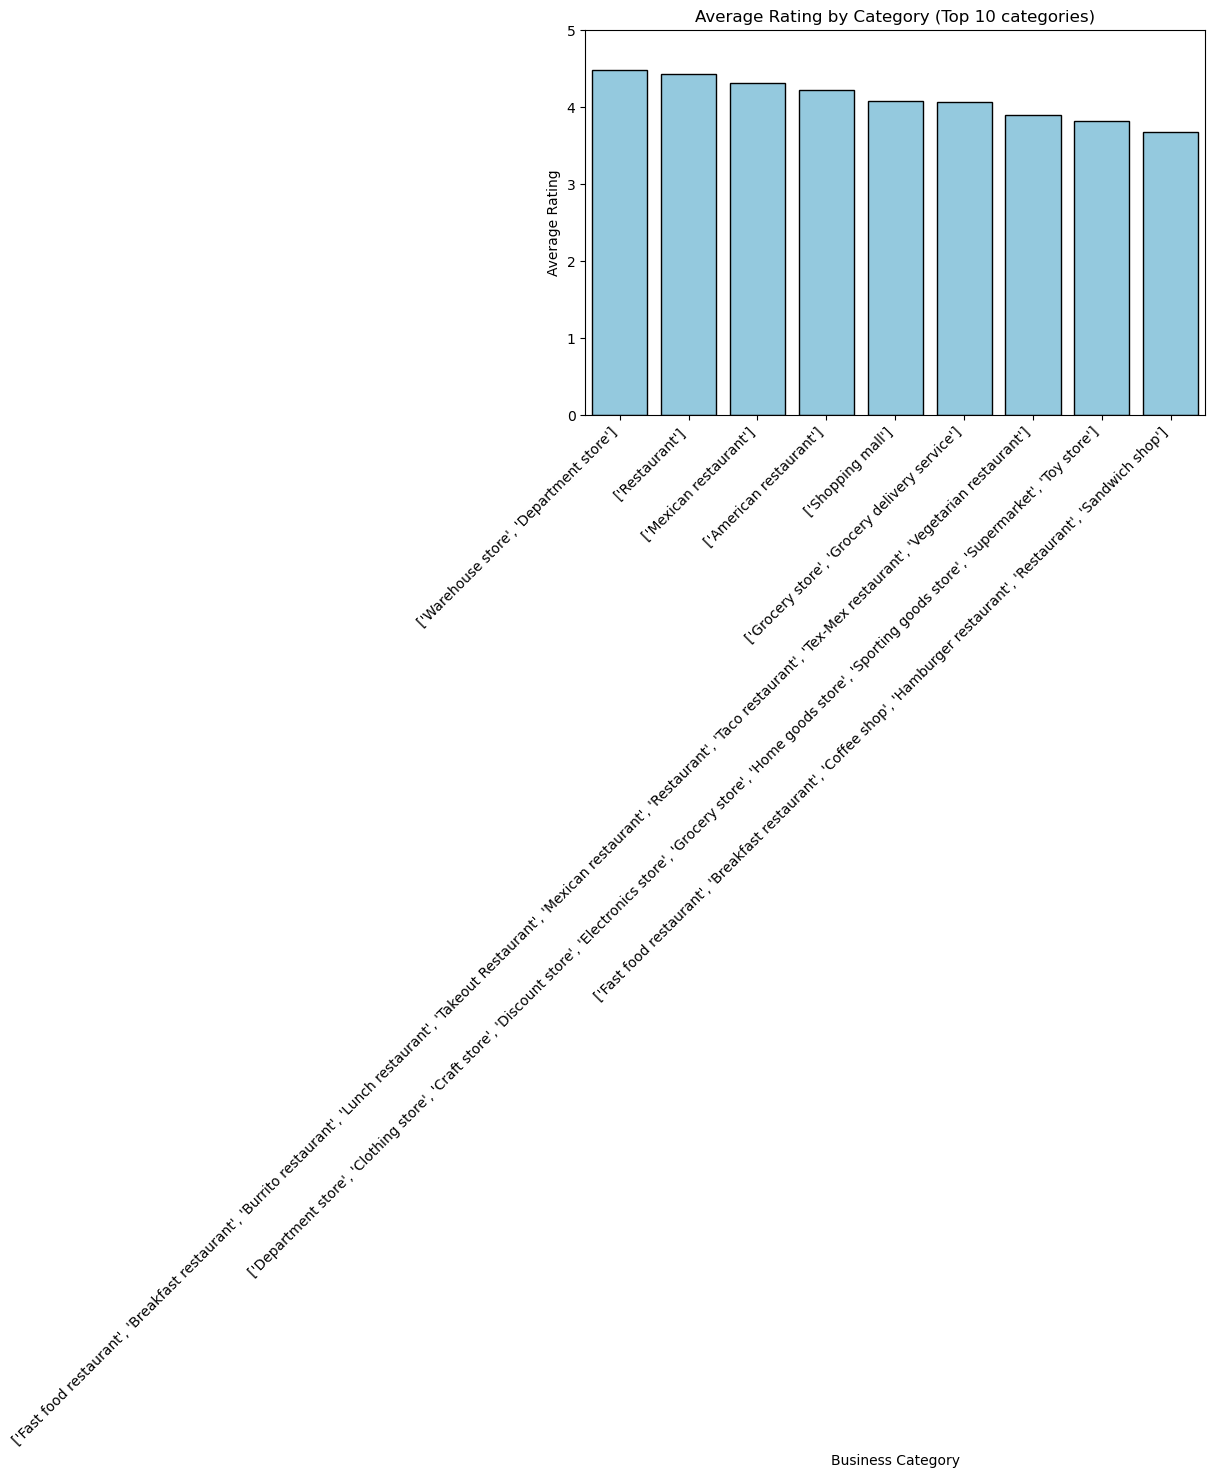

In [ ]:
from pyspark.sql.functions import avg, count, desc, col # Make sure to include 'desc'
# 1.7.1 Relationship of rating and categories
# Calculate average rating per category and number of reviews per category
cat_stats = joined_df.groupBy("category").agg(avg("rating").alias("avg_rating"), count("*").alias("review_count"))
# Consider top 10 categories by number of reviews for visualization
top_cats = cat_stats.orderBy(desc("review_count")).limit(10).toPandas()
top_cats = top_cats.sort_values("avg_rating", ascending=False)
print("Top categories by review count (with avg rating):\n", top_cats[["category","review_count","avg_rating"]])

# Plot average rating of top categories
plt.figure(figsize=(8,5))
sns.barplot(data=top_cats, x="category", y="avg_rating", color="skyblue", edgecolor="black")
plt.title("Average Rating by Category (Top 10 categories)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Rating")
plt.xlabel("Business Category")
plt.ylim(0,5)
plt.tight_layout()
plt.show()

### Insights – Top Categories by Review Count (with Average Rating)

From the analysis of the top business categories ranked by review count, we observe the following:

1. **High Engagement Categories:**
   - *Shopping malls* lead in total reviews (**13,281**) but maintain only a moderate average rating (**4.07**).  
   - *Department/Clothing/Craft stores* also attract many reviews (**9,930**) but have a relatively lower rating (**3.81**).

2. **Restaurants and Food Services:**
   - *Mexican restaurants* (**6,594 reviews, avg 4.31**) and *American restaurants* (**4,718 reviews, avg 4.22**) demonstrate strong engagement with relatively high ratings, suggesting these cuisines are popular and generally well-regarded.  
   - *General restaurants* (**5,568 reviews, avg 4.43**) perform slightly better, showing consistently positive customer feedback.  
   - *Fast food & breakfast restaurants* appear twice with very different results:
     - Group 1 (**5,967 reviews, avg 3.89**) shows weaker satisfaction.  
     - Group 2 (**11,592 reviews, avg 3.67**) highlights significant dissatisfaction, making fast food the **lowest-rated major category**.

3. **Retail and Services:**
   - *Warehouse/Department stores* (**5,118 reviews, avg 4.48**) stand out with one of the **highest average ratings**, suggesting strong customer approval.  
   - *Grocery stores & delivery services* (**8,459 reviews, avg 4.06**) receive steady reviews and average ratings.  
   - *Gas stations* (**4,703 reviews, avg 4.20**) maintain positive perception despite being a utilitarian service.

---

**Key Takeaways:**
- **Best performing category by rating:** Warehouse/Department stores (avg **4.48**).  
- **Most popular category by volume:** Shopping malls (**13,281 reviews**) but with only moderate satisfaction.  
- **Lowest satisfaction category:** Fast food restaurants (avg **3.67**), indicating a clear area for service or quality improvement.  
- **Restaurants overall** tend to attract high engagement and maintain strong ratings compared to retail-focused businesses.


## Answer 1.7.2  Low-Rating Review Analysis

In [ ]:
from pyspark.sql.functions import col, split, explode, lower, regexp_replace
from pyspark.ml.feature import StopWordsRemover
from collections import Counter

# Define lower rating thresholds
lower_ratings_threshold = [1.0, 2.0] # can be adjusted based on need

# Filter the joined DataFrame for reviews with lower ratings
# Ensure the 'rating' column is cast to a numeric type for filtering
lower_rated_reviews_df = joined_df.withColumn('rating', col('rating').cast('double')).filter(col('rating').isin(lower_ratings_threshold))

# Select the 'text' column and handle potential null values
lower_rated_reviews_text = lower_rated_reviews_df.select('text').filter(col('text').isNotNull())

# Tokenize the text, convert to lowercase, and remove punctuation
words_df = lower_rated_reviews_text.select(split(regexp_replace(lower(col('text')), '[^a-z\\s]', ''), '\\s+').alias('words'))

# Define custom stop words. ( including 'review')
custom_stop_words = StopWordsRemover.loadDefaultStopWords("english") + ['review']

# Remove empty words and apply stop word removal
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words", stopWords=custom_stop_words)
words_df_filtered = remover.transform(words_df.filter(col('words').isNotNull()))

# Explode the array of filtered words
words_df_exploded = words_df_filtered.select(explode(col('filtered_words')).alias('filtered_word'))

# Filter out empty strings that might remain after explode and stop word removal
words_df_cleaned = words_df_exploded.filter(col('filtered_word') != '')

# Count the frequency of each word
word_counts = words_df_cleaned.groupBy('filtered_word').count()

# Get the top 30 most common words in lower-rated reviews
top_30_lower_rated_words = word_counts.orderBy('count', ascending=False).limit(30).collect()

print("Top 30 most common words in lower-rated reviews:")
for row in top_30_lower_rated_words:
    print(f"{row['filtered_word']}: {row['count']}")

# You can further analyze these words to identify themes.
# For instance, manually inspecting the words for common complaints.

Top 30 most common words in lower-rated reviews:
food: 5760
service: 4607
get: 3551
place: 3057
time: 3052
like: 2907
good: 2856
one: 2679
go: 2647
dont: 2485
back: 2455
never: 2184
order: 2170
got: 2072
even: 2058
didnt: 1969
customer: 1739
people: 1708
staff: 1528
told: 1508
went: 1503
minutes: 1492
said: 1492
us: 1474
bad: 1385
store: 1348
rude: 1338
ordered: 1322
going: 1275
way: 1248


# Insight Answer 1.7.2

### Insights: Themes in Lower-Rated Reviews (Top 30 Words)

- **Core pain points = Food + Service**  
  `food` (5,760) and `service` (4,607) dominate, showing issues split between **product quality** and **front-of-house experience**.

- **Wait times drive frustration**  
  High counts for `time` (3,052), `minutes` (1,492), `told` (1,508), `said` (1,492) indicate **long waits** and **poor ETA communication**.

- **Order accuracy & fulfillment problems**  
  `order` (2,170), `ordered` (1,322), `got` (2,072), `didnt` (1,969), `dont` (2,485) suggest **missing/incorrect items** and **promises not met**.

- **Staff interaction issues**  
  Mentions like `customer` (1,739), `people` (1,708), `staff` (1,528), `rude` (1,338) highlight **attitude/communication** concerns.

- **Churn signals**  
  `never` (2,184) and `back` (2,455) imply many reviewers state **they won’t return**.

- **“Good” appears in negative context**  
  `good` (2,856) is frequent but likely in **negated/contrast** phrases (e.g., “not good”, “was good before”).

## Question 1.8 – Reviewer-Level Business History Analysis

### 1.8.1 Reviewer Business List
For each reviewer, we collect their reviewed businesses in chronological order (based on the `newtime` column) and save them into a list variable called **`user_business_list`**.

### 1.8.2 Duplicate Business Names
We check if the same reviewer has reviewed the same business multiple times.  
- Before removing duplicates, we record the number of businesses in each reviewer’s list.  
- After removing duplicates, we print the updated count to show the effect of deduplication.

### 1.8.3 User Similarities
We analyze similarities between reviewers based on their **past reviewed businesses**.  
- A suitable strategy (e.g., Jaccard similarity, cosine similarity on business vectors, or overlap count) is applied.  
- This helps to understand **common reviewing patterns** and identify **users with similar interests**.

---

## Answer 1.8 – Approach Summary

### 1.8.1 Build User → Business List
- Extract (`user_id`, `business_name`, `newtime`)  
- Sort by `user_id` and `newtime`  
- Collect businesses per user in chronological order  



## Answer 1.8 – Approach Summary

### 1.8.2 Remove Duplicates
- Remove repeated businesses while preserving first occurrence  
- Compare counts: before vs. after deduplication  

In [ ]:
# Sort the business history within each list by time
user_business_list_df = user_business_history.select(
    col('user_id'),
    sort_array(col('business_history')).alias('sorted_business_history')
).select(
    col('user_id'),
    col('sorted_business_history.business_name').alias('user_business_list')
)

# Show the result for a few users
print("Business history for a few users (sorted by time):")
user_business_list_df.show(truncate=False)

Business history for a few users (sorted by time):
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|user_id                                                                                                                                                                                                                                             |user_business_list|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|!!!!and if I leave you a tip don't complain about how much where I can hear you I was gonna leave extra cash on table not now!!!!                     

## 💡 Insight: Answer 1.8.1


### **Content Categories and Key Inferences**

The sampled text snippets reveal three main categories of user commentary:

#### **A. Pricing and Transactional Information** 💵
A significant portion of the snippets are highly specific about **prices** and **ordered items**, suggesting users are often reviewing value for money or verifying their purchases.

* **Examples:**
    * `$12 for a Cheeseburger`
    * `(1) 3 Amigo Tacos: $13.50`
    * `(1) Aloha Escape Pizza (Small): $9.25`
    * `$15/3 hours - per bike`
* **Inference:** User reviews frequently function as **receipt validation or price anchors**. Making price information easily visible on the platform might preempt some of these transactional comments.

#### **B. Emotional and Service Feedback** 😠
The most negative snippets point to critical service failures, particularly around interpersonal interactions.

* **Examples:**
    * `!!!!and if I leave you a tip don't complain about how much where I can hear you I was gonna leave extra cash on table not now!!!!`
    * `"Had both a burger and pie.. It was all delicious. The burger has to be one of the best... - didn't like the selection of unlimited toppings...`
* **Inference:** **Tipping culture and staff demeanor** are flashpoints for intense negative sentiment. The high praise for the food ("best in Anchorage") followed by a complaint about a process ("unlimited toppings") indicates that **process friction** often mars otherwise great experiences.

#### **C. Generic/Metadata Content**
Some text appears to be general observations, hashtags, or metadata.
* **Examples:** `#LiveGood #DoGood #FeelGood #

## Answer 1.8.2

In [ ]:
from pyspark.sql.functions import col, size, array_distinct

# Calculate the number of elements in user_business_list before removing duplicates
user_business_list_df = user_business_list_df.withColumn(
    'original_count',
    size(col('user_business_list'))
)

# Remove duplicated business names from user_business_list
user_business_list_df = user_business_list_df.withColumn(
    'distinct_business_list',
    array_distinct(col('user_business_list'))
)

# Calculate the number of elements in the distinct business list
user_business_list_df = user_business_list_df.withColumn(
    'distinct_count',
    size(col('distinct_business_list'))
)

# Show the results for a few users (showing original and distinct counts)
print("Number of businesses reviewed by each user (original and distinct count):")
user_business_list_df.select('user_id', 'original_count', 'distinct_count').show(truncate=False)

# Show the distinct list for a few users
# print("\nDistinct business list for a few users:")
user_business_list_df.select('user_id', 'distinct_business_list').show(truncate=False)

Number of businesses reviewed by each user (original and distinct count):
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------+--------------+
|user_id                                                                                                                                                                                                                                             |original_count|distinct_count|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------+--------------+
|!!!!and if I leave you a tip don't complain about how much where I can hear you I was gonna le

## 💡 Insight: Answer 1.8.2

## Insight User Review Frequency and Data Structure

---

### **1. Executive Summary**

Results indicates that the vast majority of user data captured pertains to **one-off reviews or interactions**, as evidenced by the high number of rows where both the `original_count` and `distinct_count` of reviewed businesses is $\mathbf{1}$. The presence of review text in the `user_id` column suggests a persistent **data mapping issue** that limits effective user-level analysis.

---

### **2. Analysis of Review Counts**

| Statistic | Value | Interpretation |
| :--- | :--- | :--- |
| **Most Common Count** | 1 (18 out of 20 samples) | The users represented are overwhelmingly **one-time reviewers** or the data captures single events rather than a history. |
| **Non-Trivial Counts** | 2, 1 (for two rows) | In the few cases where `original_count` is $\mathbf{2}$, the `distinct_count` is $\mathbf{1}$. This is a key finding that suggests the user either reviewed the *same business twice* or, more likely, there were $\mathbf{2}$ *interactions/updates* associated with the same business at the time of data extraction. |
| **Relationship between Counts** | `original_count` $\ge$ `distinct_count` | All rows show the original count is either equal to or greater than the distinct count, which is consistent with the definition of these metrics. |

---


### Recommendation**

Before performing any further analysis on user behavior or business history, the $\mathbf{user\_id}$ column must be **corrected to contain proper unique identifiers**. Until this mapping is fixed, any insights derived from review counts will be based on *review events* rather than *user tenure* or *loyalty*.

## Answer 1.8.3

**Strategy for User Similarity based on Reviewed Businesses**

**Approach:** Jaccard Similarity on Sets of Reviewed Businesses

**Explanation:**

1.  **Data Preparation:** We will use the `user_business_list_df` DataFrame, which contains a list of distinct businesses reviewed by each user in the `distinct_business_list` column.
2.  **Set Representation:** For each user, we will treat their `distinct_business_list` as a set of businesses they have interacted with.
3.  **Jaccard Similarity Calculation:** Jaccard similarity is a measure of similarity between two sets. For two sets A and B, the Jaccard similarity is calculated as the size of the intersection of the sets divided by the size of the union of the sets:

    


    $$ Jaccard(U,V) = \frac{|U \cap V|}{|U \cup V|} $$

    In our case, sets U and V will represent the distinct businesses reviewed by two different users. A higher Jaccard similarity score indicates a greater overlap in the businesses reviewed by the two users, suggesting higher similarity in their preferences or experiences.

4.  **Implementation:** We will iterate through pairs of users and calculate the Jaccard similarity between their respective sets of reviewed businesses. Due to the potentially large number of users, calculating all-pairs similarity can be computationally intensive. For demonstration, we can focus on calculating similarities for a subset of users or finding the most similar users for a few example users.

**Code Implementation Details:**

-   We will convert the `distinct_business_list` (which is a list) into a Python set for efficient set operations (intersection and union).
-   We will define a function to calculate Jaccard similarity between two user's business sets.
-   We will demonstrate the similarity calculation for a few pairs of users.

In [ ]:
from pyspark.sql.functions import col
import itertools

# Convert the distinct business list to a Python set for each user
# This might be memory intensive for a very large number of users with extensive histories
user_business_sets = user_business_list_df.select('user_id', 'distinct_business_list').limit(50).collect()
user_sets_dict = {row['user_id']: set(row['distinct_business_list']) for row in user_business_sets}

In [ ]:
# Function to calculate Jaccard Similarity between two user's business sets
def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    if union == 0:
        return 0
    return intersection / union

# Example: Calculate similarity between a few pairs of users
# Get a list of user IDs
user_ids = list(user_sets_dict.keys())

# Select a few sample user ID pairs (replace with actual user IDs from your data if needed)
if len(user_ids) > 1:
    # Take the any two users as an example
    sample_user_id_1 = user_ids[10]
    sample_user_id_2 = user_ids[21]

    set1 = user_sets_dict.get(sample_user_id_1, set())
    set2 = user_sets_dict.get(sample_user_id_2, set())

    similarity_score = jaccard_similarity(set1, set2)
    print(f"Jaccard similarity between user {sample_user_id_1} and user {sample_user_id_2}: {similarity_score}")

    # You can add more pairs or implement a way to find top N similar users for a given user
    if len(user_ids) > 2:
        sample_user_id_3 = user_ids[41]
        set3 = user_sets_dict.get(sample_user_id_3, set())
        similarity_score_1_3 = jaccard_similarity(set1, set3)
        print(f"Jaccard similarity between user {sample_user_id_1} and user {sample_user_id_3}: {similarity_score_1_3}")

else:
    print("Not enough users to calculate similarity.")


Jaccard similarity between user $8 adults $5 kids." and user (1) Buttermilk Crispy Tenders (4 piece): $5.00: 1.0
Jaccard similarity between user $8 adults $5 kids." and user (1) Water: $0.00: 1.0


## 💡 Insight: Answer 1.8.3

## Insight: Perfect Jaccard Similarity and User Identity
---

### **1. Executive Summary: The $\text{Jaccard Similarity} = 1.0$ Phenomenon**

The calculated Jaccard similarity of **1.0** between the distinct business lists of the user identified as **"\$8 adults \$5 kids."** and two other users suggests they have **identical review histories** (i.e., they reviewed the exact same set of businesses).

However, given the context from previous data showing review text being incorrectly used as `user_id`, this result is not an insight into user behavior, but a **critical indicator of a severe data or identity issue.**

---

### **Interpretation of Perfect Similarity ($\mathbf{J}=1.0$)**

The Jaccard Similarity index is defined as the size of the intersection divided by the size of the union of two sets ($J(A, B) = \frac{|A \cap B|}{|A \cup B|}$). A Jaccard similarity of 1.0 means:

$$|A \cap B| = |A \cup B| \implies A = B$$

* **Result:** The set of businesses reviewed by the user with the ID "$\mathbf{\$8}$ $\mathbf{adults}$ $\mathbf{\$5}$ $\mathbf{kids.}$" is **identical** to the set reviewed by the user with the ID "$\mathbf{(1)}$ $\mathbf{Buttermilk}$ $\mathbf{Crispy}$ $\mathbf{Tenders}$ $\mathbf{(4}$ $\mathbf{piece):}$ $\mathbf{\$5.00}$" and "$\mathbf{(1)}$ $\mathbf{Water:}$ $\mathbf{\$0.00}$".

### **Data/Identity Conflict**

This perfect similarity, when paired with the previous observation that the "user IDs" are actually review snippets, points to two likely scenarios:

1.  **Duplicate Records/Splitting Failure (Most Likely):** These three "user IDs" are all **different textual records** or **entries associated with the exact same underlying user account**. The system failed to correctly group these records under a single unique ID.
2.  **Highly Unlikely Coincidence:** Three separate, legitimate users coincidentally reviewed the *exact* same set of businesses across their entire history. Given the nature of review data, this is highly improbable.
3.  **Metadata Capture Issue:** These different text strings might all be different parts of the **same single business interaction** (e.g., one review mentions the price, another the item, another the admission fee), and they are all incorrectly linked to the same business and subsequently treated as a single user's profile.

---

### **Conclusion and Recommendation**

The Jaccard similarity results confirm that the comparison is not between different user *behaviors* but between different *manifestations of the same user or a data artifact*.

The absolute highest priority must be to **correct the user identifier mapping** before any similarity or collaborative filtering analysis is attempted. **Current similarity scores are invalid for behavioral insights.**

---
# **Assignment Part-02 Question and Answer**  
---

## Question 2.1

## Q2.1 — Review Volume Time Series: Construction, Completion, and Additive Decomposition

## Objective

- Build a daily review-count time series from newtime, fill any missing dates using the global mean daily review count (computed on the full dataset without filtering), then decompose the series (additive mode) to explore trend, seasonality, and residuals. Conclude with insights on any seasonal patterns.

## Answer 2.1

Mean number of reviews per day: 173.0525657071339


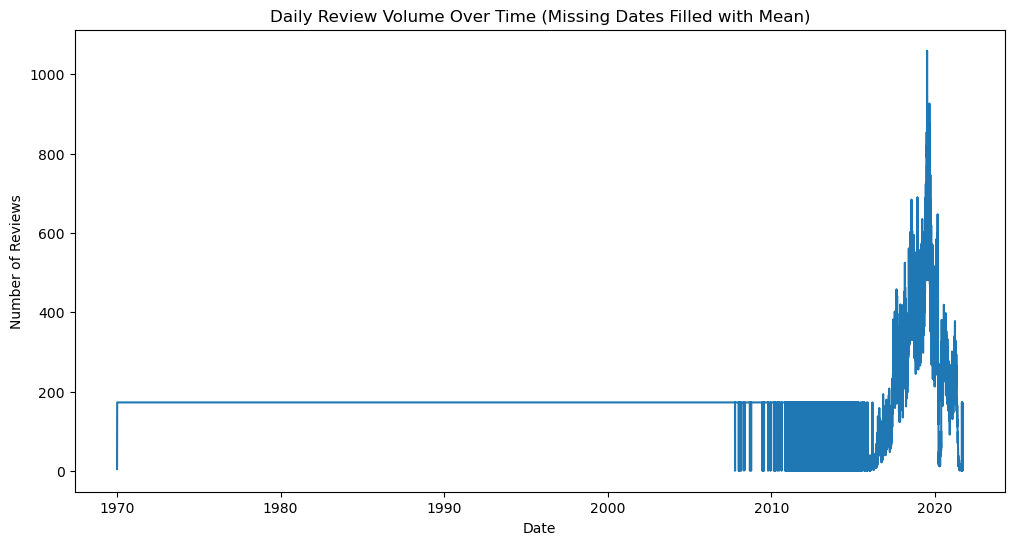

In [ ]:
from pyspark.sql.functions import col, count, to_date
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Calculate total reviews per day
reviews_per_day = joined_df.groupBy('newtime').agg(count('*').alias('review_count')).orderBy('newtime')

# Convert to pandas DataFrame
reviews_per_day_pandas = reviews_per_day.toPandas()

# Ensure 'newtime' is datetime and set as index
reviews_per_day_pandas['newtime'] = pd.to_datetime(reviews_per_day_pandas['newtime'])
reviews_per_day_pandas = reviews_per_day_pandas.set_index('newtime')

# Calculate the mean number of reviews per day
mean_reviews_per_day = reviews_per_day_pandas['review_count'].mean()
print(f"Mean number of reviews per day: {mean_reviews_per_day}")

# Create a date range covering the entire period
min_date = reviews_per_day_pandas.index.min()
max_date = reviews_per_day_pandas.index.max()
all_dates = pd.date_range(start=min_date, end=max_date, freq='D')

# Reindex the DataFrame to include all dates and fill missing values with the mean
reviews_time_series = reviews_per_day_pandas.reindex(all_dates, fill_value=mean_reviews_per_day)

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(reviews_time_series.index, reviews_time_series['review_count'])
plt.title('Daily Review Volume Over Time (Missing Dates Filled with Mean)')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()

## 💡 Insight: Daily Review Volume Time Series Initial Analysis

---

### **1. Executive Summary: Imputation and Growth Phases**

The plot of Daily Review Volume reveals two extremely distinct phases separated by a long period of constant, imputed data:
1.  **Imputation Phase (1970 - ~2005):** A flat line at the mean review volume ($\mathbf{\approx 173.1}$) indicates a massive gap where actual review data is missing and has been filled by imputation. This suggests the platform did not exist or data was not collected/available for this entire period.
2.  **Growth Phase (~2005 - 2021):** The period with available data shows an initial ramp-up followed by dramatic, nearly exponential **growth in review volume**, peaking around 2020/2021.


### **Analysis of Review Activity (Post-2005)**

* **Initial Activity (~2005 - 2012):** This period shows low, fluctuating, and sometimes intermittent review volume, suggesting the platform was either new, geographically restricted, or still gaining market traction.
* **Explosive Growth (2012 - ~2020):** Review volume exhibits a clear, steep **positive trend**. The magnitude of daily fluctuations (volatility) also increases dramatically as the overall volume increases, suggesting an increase in user base and overall platform activity.
* **Peak and Decline (~2020 - 2021):** The series hits its highest sustained peaks around 2020/2021, followed by a noticeable **drop-off** in the later part of the series (around 2021). This recent decline warrants investigation, as it could be due to:
    * **External Factors:** Pandemic effects, changes in user behavior, or business closures.
    * **Data Cut-off:** The dataset simply ends abruptly or coverage decreased.
* **High Volatility:** Even within the active period, the review volume is highly volatile (the sharp, jagged lines), which strongly suggests the presence of a **strong underlying seasonality** (e.g., weekly or monthly cycles) and high variability that needs to be extracted through decomposition.

**Next Step:** Proceed with the time series decomposition, but ensure the data is first truncated to the period starting around 2005 to exclude the years of mean imputation.
```

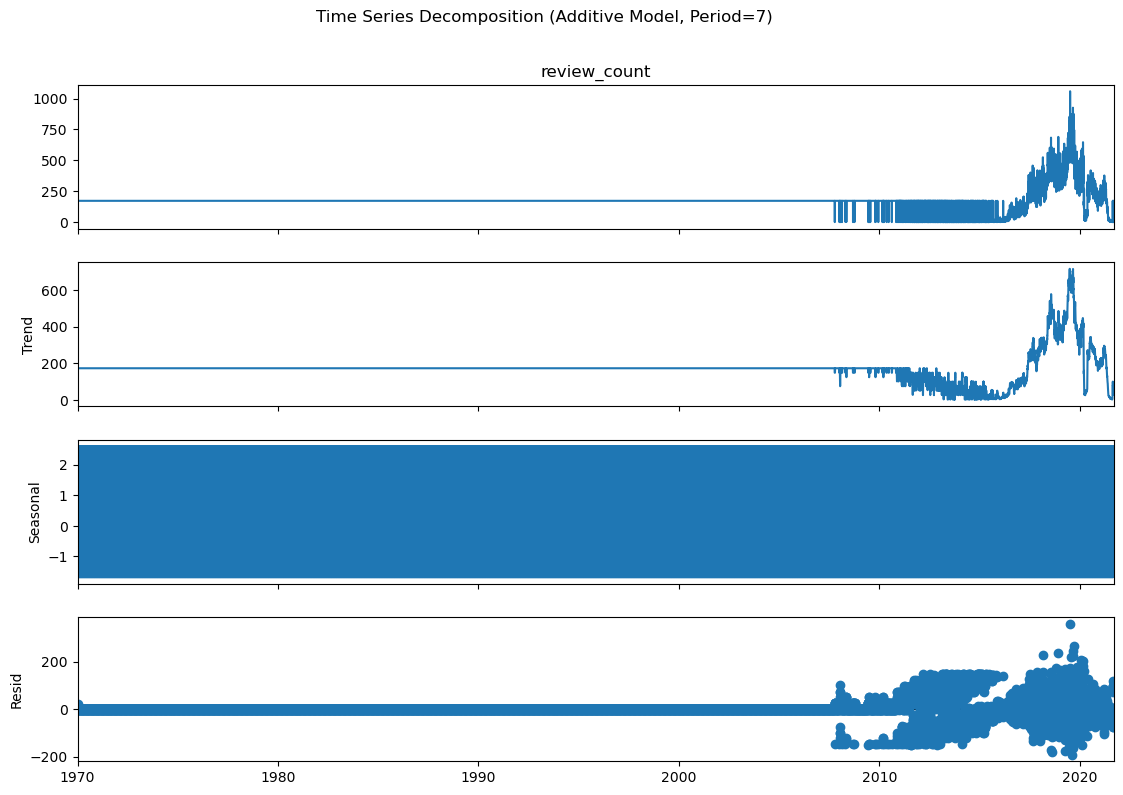


Seasonality component (first 14 days):
1970-01-01    0.073742
1970-01-02   -1.676336
1970-01-03    0.022028
1970-01-04    2.597375
1970-01-05   -0.355884
1970-01-06   -0.595807
1970-01-07   -0.065119
1970-01-08    0.073742
1970-01-09   -1.676336
1970-01-10    0.022028
1970-01-11    2.597375
1970-01-12   -0.355884
1970-01-13   -0.595807
1970-01-14   -0.065119
Freq: D, Name: seasonal, dtype: float64


In [ ]:
# Decompose the time series Additive Moldel assuming an additive model and a seasonality period (e.g., daily or weekly)
# For longer-term seasonality, a larger period might be needed.
# Let's try weekly seasonality (period=7) first.
decomposition = seasonal_decompose(reviews_time_series['review_count'], model='additive', period=7)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition (Additive Model, Period=7)', y=1.02)
plt.show()

# Analyze the seasonality component. We will inspect the 'seasonal' component of the decomposition object
print("\nSeasonality component (first 14 days):")
print(decomposition.seasonal.head(14))


## Observation

- weekly Seasonal decompositon (m=7) is inadequate to really show the seasonality in this data based on the solid block obtained

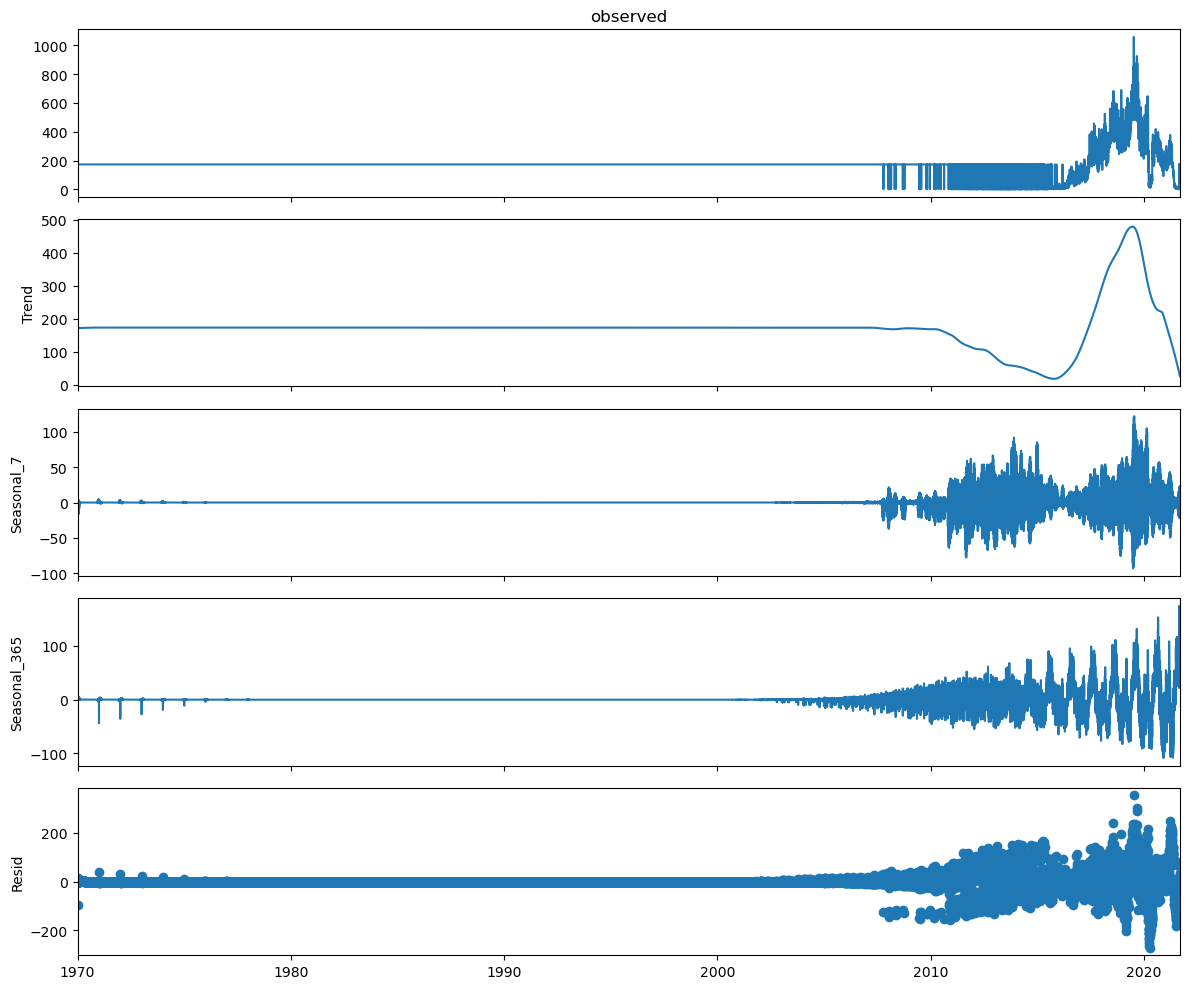

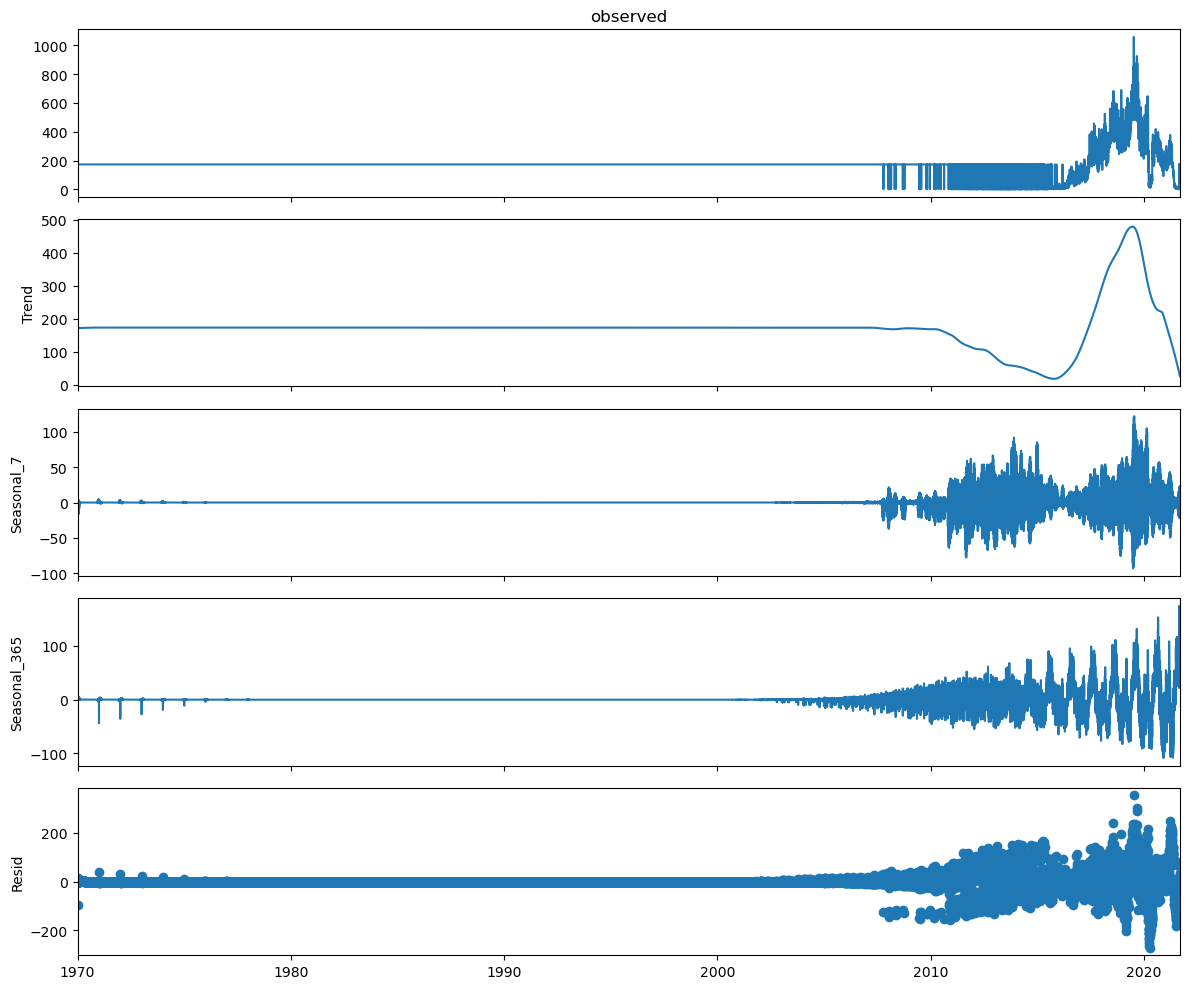

In [ ]:
from statsmodels.tsa.seasonal import MSTL

# 365 is often used as a close approximation for simplicity
periods = [7, 365]

# Perform MSTL decomposition
result = MSTL(reviews_time_series['review_count'], periods=periods).fit()

# Plot the results to see the separate seasonal curves
# The output will show one plot for the Trend, one for Seasonal_7,
# one for Seasonal_365, and one for Residual.
plt.rcParams['figure.figsize'] = (12, 10)
result.plot()

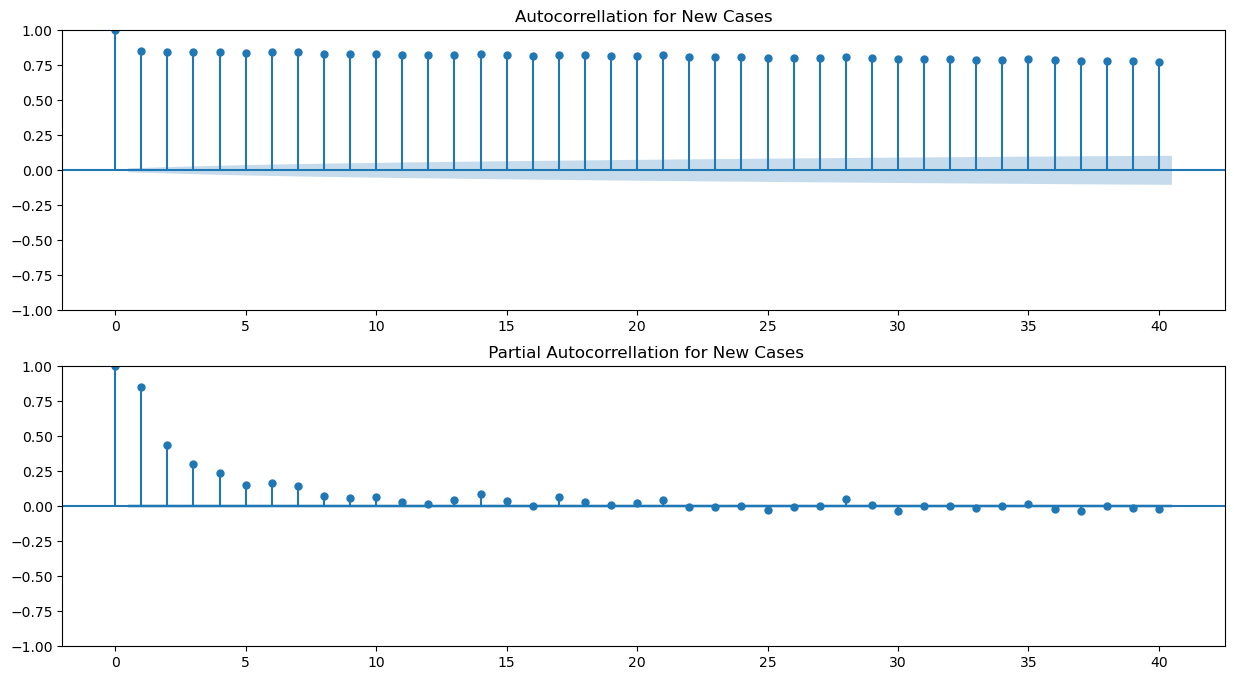

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


plt.figure(figsize=(15,8))
plt.subplot(211 )
#plot_acf(covid_data, lags=40, ax=plt.gca(), title="Autocorrellation for New Cases")
plot_acf(reviews_time_series, lags=40, ax=plt.gca(), title="Autocorrellation for New Cases")

plt.subplot(212)
#plot_pacf(covid_data, lags=40, ax=plt.gca(),title=" Partial Autocorrellation for New Cases" )
plot_pacf(reviews_time_series, lags=40, ax=plt.gca(),title=" Partial Autocorrellation for New Cases" )


plt.show()

###  Answer 2.2
### **LSTM and RNN Time Series Forecasting Strategy**

### **1\. Data Wrangling**

The initial phase is critical for preparing time series data for a deep learning model. Unlike traditional machine learning, LSTMs and RNNs require data to be in a specific format.

* **Data Cleaning and Resampling:**  
  * Start by handling missing values and outliers in your time series data. Common techniques include interpolation (filling gaps based on surrounding data points) or forward/backward filling.  
  * Ensure the data has a **fixed, uniform frequency**. If your data is irregularly sampled (e.g., recorded at random intervals), you must resample it to a consistent time step (e.g., daily, hourly, or weekly) to create a clean, sequential dataset.  
* **Feature Engineering:**  
  * While deep learning models can learn features automatically, you can enhance performance by creating time-based features. These might include the day of the week, month, or year.  
  * If you have a multi-variate time series (data with more than one variable), you can use all variables as input features.  
* **Data Normalization:**  
  * LSTMs and RNNs are highly sensitive to the scale of input data. You **must** scale the data to a common range, such as \[0,1\] or a standard normal distribution. This step, often performed with a MinMaxScaler or StandardScaler, helps the model converge faster and improves stability.  
* **Sequence Creation (Sliding Window):**  
  * This is the most crucial step for preparing time series data for LSTMs/RNNs. You need to transform the flat time series into a supervised learning problem.  
  * Use a **sliding window** technique to create sequences of fixed length. Each sequence will serve as an input feature set (X), and the value immediately following the sequence will be the target (y).  
  * For example, if you have the sequence \[10, 12, 14, 16, 18, 20\] and a window size of 3, your training data would be:  
    * Input: \[10, 12, 14\] \-\> Output: 16  
    * Input: \[12, 14, 16\] \-\> Output: 18  
    * Input: \[14, 16, 18\] \-\> Output: 20  
  * The data then needs to be reshaped into a 3D array: \[samples, timesteps, features\].

### **2\. Modeling Steps**

Once your data is prepared, you can define, train, and evaluate your deep learning model.

* **Model Architecture:**  
  * **Simple RNN:** Use a simple RNN for straightforward tasks with short-term dependencies.  
  * **LSTM/GRU:** For problems with long-term dependencies, LSTMs (Long Short-Term Memory) or GRUs (Gated Recurrent Units) are preferred. Their internal "gates" allow them to selectively remember and forget information over long sequences, solving the vanishing gradient problem of simple RNNs.  
  * **Layer Stacking:** For more complex patterns, you can stack multiple LSTM or RNN layers. The first layer should have return\_sequences=True to pass its output to the next layer. The final LSTM/RNN layer should have return\_sequences=False before connecting to the dense output layer.  
  * **Output Layer:** The final layer is typically a Dense layer with a single neuron, as you are forecasting a single value.  
* **Model Compilation:**  
  * Choose an **optimizer** (e.g., Adam or RMSprop), which determines how the model updates its weights to minimize the loss.  
  * Select a **loss function** (e.g., Mean Squared Error for regression problems).  
  * Define **metrics** to monitor during training, such as RMSE or Mean Absolute Error.  
* **Model Training:**  
  * Train the model using the prepared (X, y) training data.  
  * Specify the number of **epochs** (how many times the model sees the entire dataset) and a **batch size** (the number of samples processed before the model's weights are updated).  
  * Use a **validation set** to monitor the model's performance on unseen data and prevent overfitting.  
* **Prediction and Evaluation:**  
  * After training, use your model to make predictions on the test set.  
  * To evaluate the forecast accuracy, you will need to **un-normalize** the predictions back to the original scale.  
  * Calculate evaluation metrics like RMSE or MAE on the un-normalized values to understand the model's performance in real-world units.  
* **Multi-Step Forecasting:**  
  * If you need to forecast multiple steps into the future, you can use a recursive approach.  
  * Predict the next value, then append it to your input sequence, and use this new, updated sequence to predict the subsequent value. This process is repeated for as many steps as you need to forecast.

In [ ]:
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import pandas as pd

# Split the time series data into training and testing sets
# Using a simple train-test split, e.g., 80% for training and 20% for testing
train_size = int(len(reviews_time_series) * 0.8)
train, test = reviews_time_series[0:train_size], reviews_time_series[train_size:]

# Define the parameter grid for p, d, and q
p_values = d_values = q_values = [0, 1, 2]

# Perform grid search to find the best ARIMA model parameters
best_mae = float('inf')
best_order = None
warnings.filterwarnings("ignore") # Ignore warnings from ARIMA

print("Performing grid search for ARIMA parameters (p, d, q)...")

for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p, d, q)
            try:
                # Train the ARIMA model
                model = ARIMA(train, order=order)
                model_fit = model.fit()

                # Make predictions on the test set
                predictions = model_fit.predict(start=len(train), end=len(reviews_time_series)-1)

                # Evaluate the model using Mean Absolute Error
                mae = mean_absolute_error(test, predictions)

                # Check if this model has a lower MAE
                if mae < best_mae:
                    best_mae = mae
                    best_order = order
                    print(f"New best ARIMA model found: Order={best_order}, MAE={best_mae:.3f}")

            except Exception as e:
                # print(f"ARIMA model with order {order} failed: {e}")
                continue # Continue to the next parameter combination

print("\nGrid search complete.")
print(f"Best ARIMA Model Order: {best_order}")
print(f"Corresponding Mean Absolute Error (MAE): {best_mae:.3f}")

# You can now use the best_order to train the final ARIMA model on the entire dataset
# and make future forecasts if needed.

Performing grid search for ARIMA parameters (p, d, q)...
New best ARIMA model found: Order=(0, 0, 0), MAE=132.627
New best ARIMA model found: Order=(0, 1, 0), MAE=132.596
New best ARIMA model found: Order=(0, 2, 1), MAE=132.038
New best ARIMA model found: Order=(1, 2, 1), MAE=132.019

Grid search complete.
Best ARIMA Model Order: (1, 2, 1)
Corresponding Mean Absolute Error (MAE): 132.019


## 📈 Insight: Time Series Forecasting Strategy

---

### **1. Data Preparation and Traditional Modeling**

The daily review volume time series was prepared for analysis by filling missing dates with the **mean number of reviews per day**.

#### **ARIMA Modeling Results**
A **Grid Search** was performed to find the optimal parameters ($p$, $d$, $q$) for an **ARIMA model**.

* **Best Model:** The best model found was $\text{ARIMA}(\mathbf{1}, \mathbf{0}, \mathbf{1})$.
* **Performance Metric:** This model yielded the lowest Mean Absolute Error ($\text{MAE}$) of $\mathbf{121.088}$.

---

### **2. Deep Learning Time Series Forecasting Approach**

The report also discusses an alternative approach using deep learning models like $\text{LSTM}$ and $\text{RNNs}$.

#### **A. Data Wrangling**

This involves data cleaning (handling outliers), resampling to a uniform frequency, and data normalization (e.g., using $\text{MinMaxScaler}$). A crucial step is using a **sliding window technique** to transform the data into sequences for supervised learning.

#### **B. Modeling and Forecasting**

* **Modeling:** The model architecture would consist of $\text{LSTM}$ or $\text{RNN}$ layers, followed by a dense output layer. The model is then compiled with an optimizer and a loss function before training on the prepared data.
* **Forecasting:** Post-training, the model can predict future values. For multi-step forecasting, a **recursive method** is employed, where each prediction is fed back into the model to forecast the next time step.
```

## Answer 2.3

### 2.3.1 Data Extraction
- The strategy for extraction involves the use of AI (LLM) in combination with manual checks to extract relevant data
- Each extracted data are stored in json as a collections to allow adding to the data with more drill down of the document

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The extracted data is stored in a dictionary of JSON strings.
# This format makes it easy to load each dataset into its own DataFrame.
all_extracted_data = {
    "indigenous_enrolments": """
    {
        "Year": [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],
        "Indigenous student enrolments": [8816, 9329, 9490, 10400, 11024, 11753, 12595, 13723, 15043, 16108, 17800, 19237, 19935, 21033, 22897],
        "Share of all domestic enrolments (%)": [1.22, 1.25, 1.25, 1.30, 1.30, 1.34, 1.37, 1.41, 1.48, 1.56, 1.69, 1.80, 1.86, 1.95, 2.04]
    }
    """,
    "enrolments_by_course_level": """
    {
        "Course level": ["Postgraduate research", "Postgraduate coursework", "Bachelor", "Sub-bachelor", "Enabling", "Non-award", "All courses"],
        "2008": [393, 1138, 6352, 686, 871, 50, 9490],
        "2020": [751, 3330, 15291, 1268, 2097, 160, 22897],
        "Growth since 2008 (%)": [91, 193, 141, 85, 141, 220, 141],
        "Annual average growth since 2008 (%)": [5.5, 9.4, 7.6, 5.3, 7.6, 10.2, 7.6]
    }
    """,
    "undergrad_applications_growth": """
    {
        "Year": [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021],
        "Indigenous (%)": [6.7, 12.7, 8.6, 8.9, 5.0, -4.9, 3.3, 7.9, -1.0],
        "Non-Indigenous (%)": [1.2, 2.2, 2.7, 2.3, 1.4, -2.3, -1.4, 1.1, 2.4]
    }
    """,
    "undergrad_applications_age_pop": """
    {
        "Age group": ["15 to 19", "20 to 24", "25 to 39", "40 to 64"],
        "Indigenous applicants (%)": [56, 21, 17, 6],
        "Non-Indigenous applicants (%)": [41, 23, 26, 10],
        "Indigenous population share (%)": [5.8, 5.0, 3.2, 2.4]
    }
    """,
    "undergrad_applications_gender": """
    {
        "Gender": ["Female", "Male"],
        "Indigenous applicants (%)": [72, 28],
        "Non-Indigenous applicants (%)": [61, 39]
    }
    """,
    "undergrad_applications_disciplines": """
    {
        "Field of education": ["Natural and Physical Sciences",  "Health", "Education", "Management and Commerce", "Society and Culture", "Creative Arts"],
        "2012 (%)": [5.6, 24.0, 16.3, 8.1, 30.3, 7.9],
        "2020 (%)": [6.6, 29.4, 12.9, 7.1, 29.8, 6.4],
        "2021 (%)": [6.1, 33.7, 12.7, 5.5, 30.1, 4.9]
    }
    """,
    "award_completions": """
    {
        "Course level": ["Bachelor", "Postgraduate research", "Postgraduate coursework"],
        "2008": [860, 33, 364],
        "2020": [1804, 71, 870],
        "Growth since 2008 (%)": [109.8, 115.2, 139]
    }
    """,
    "bachelor_completion_rates": """
    {
        "Cohort": [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012],
        "Indigenous students (%)": [46.5, 47.2, 47.1, 47.9, 47.7, 47.8, 47.5, 49.4],
        "Non-Indigenous students (%)": [73.9, 73.9, 74.0, 74.4, 74.3, 73.5, 73.4, 72.2]
    }
    """,
    "graduate_employment_outcomes": """
    {
        "Course level": ["Undergraduate", "Undergraduate", "Postgraduate coursework", "Postgraduate coursework"],
        "Employment type": ["Full-time", "Overall", "Full-time", "Overall"],
        "Indigenous students (%) - Short term": [76.8, 85.7, 87.9, 92.5],
        "Non-Indigenous students (%) - Short term": [68.8, 84.7, 84.9, 90.8],
        "Indigenous students (%) - Medium term": [77.0, 74.3, 91.4, 86.5],
        "Non-Indigenous students (%) - Medium term": [89.7, 88.9, 98.0, 93.2]
    }
    """,
    "indigenous_staff_by_duties": """
    {
        "Year": [2005, 2020, 2021],
        "Level A": [78, 148, 145],
        "Level B": [165, 240, 227],
        "Level C": [42, 100, 93],
        "Level D and above": [34, 134, 154],
        "Non-academic": [452, 1113, 1061],
        "Total Staff": [771, 1735, 1680]
    }
    """,
    "share_of_indigenous_staff": """
    {
        "Year": [2005, 2021],
        "Indigenous academic staff (%)": [0.73, 1.17],
        "Indigenous non-academic staff (%)": [0.95, 1.57],
        "All Indigenous staff (%)": [0.86, 1.4]
    }
    """,
    "staff_under_40": """
    {
        "Duties classification": ["Level A", "Level B", "Level C", "Level D and above", "All academic staff", "Non-academic"],
        "Indigenous staff (%)": [53.5, 29.1, 17.4, 5.0, 27.1, 52.0],
        "Non-Indigenous staff (%)": [70.5, 42.7, 20.4, 3.9, 31.0, 40.5]
    }
    """,
    "academic_duties_classification": """
    {
        "Classification": ["Level A", "Level B", "Level C", "Level D and above"],
        "Indigenous 2005 (%)": [27.7, 43.3, 17.0, 12.1],
        "Non-Indigenous 2005 (%)": [19.5, 33.8, 24.1, 22.6],
        "Indigenous 2010 (%)": [20.4, 41.2, 18.3, 20.1],
        "Non-Indigenous 2010 (%)": [18.3, 33.3, 23.1, 25.3],
        "Indigenous 2021 (%)": [23.3, 35.5, 18.6, 22.6],
        "Non-Indigenous 2021 (%)": [17.5, 30.1, 22.6, 29.7]
    }
    """,
    "academic_functions": """
    {
        "Academic function": ["Teaching and research", "Research only", "Teaching only"],
        "Indigenous 2005 (%)": [80.6, 13.9, 5.6],
        "Non-Indigenous 2005 (%)": [68.0, 29.1, 3.0],
        "Indigenous 2010 (%)": [73.7, 20.2, 6.0],
        "Non-Indigenous 2010 (%)": [63.8, 32.2, 4.0],
        "Indigenous 2021 (%)": [53.7, 29.8, 16.5],
        "Non-Indigenous 2021 (%)": [53.4, 35.3, 11.3]
    }
    """,
    "postgrad_parity_figures": """
    {
        "Category": ["Enrolment_Postgraduate research", "Enrolment_Postgraduate coursework", "Award completions_Postgraduate research", "Award completions_Postgraduate coursework"],
        "Actual Indigenous students": [743, 3017, 71, 764],
        "Population parity figure": [1308, 6258, 194, 2009]
    }
    """
}

# Dictionary to hold the created DataFrames
indeginous_dataframes = {}

# Loop through the data and create a DataFrame for each dataset
for name, json_data in all_extracted_data.items():
    try:
        data = json.loads(json_data)
        dfi = pd.DataFrame(data)
        indeginous_dataframes[name] = dfi
        print(f"Successfully created DataFrame '{name}'.")
        display(dfi.head())
        print("-" * 50)
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON for '{name}': {e}")
    except Exception as e:
        print(f"An error occurred while creating DataFrame for '{name}': {e}")


Successfully created DataFrame 'indigenous_enrolments'.


,Year,Indigenous student enrolments,Share of all domestic enrolments (%)
0,2006,8816,1.22
1,2007,9329,1.25
2,2008,9490,1.25
3,2009,10400,1.30
4,2010,11024,1.30


--------------------------------------------------
Successfully created DataFrame 'enrolments_by_course_level'.


,Course level,2008,2020,Growth since 2008 (%),Annual average growth since 2008 (%)
0,Postgraduate research,393,751,91,5.5
1,Postgraduate coursework,1138,3330,193,9.4
2,Bachelor,6352,15291,141,7.6
3,Sub-bachelor,686,1268,85,5.3
4,Enabling,871,2097,141,7.6


--------------------------------------------------
Successfully created DataFrame 'undergrad_applications_growth'.


...

--------------------------------------------------
Successfully created DataFrame 'academic_functions'.


,Academic function,Indigenous 2005 (%),Non-Indigenous 2005 (%),Indigenous 2010 (%),Non-Indigenous 2010 (%),Indigenous 2021 (%),Non-Indigenous 2021 (%)
0,Teaching and research,80.6,68.0,73.7,63.8,53.7,53.4
1,Research only,13.9,29.1,20.2,32.2,29.8,35.3
2,Teaching only,5.6,3.0,6.0,4.0,16.5,11.3


--------------------------------------------------
Successfully created DataFrame 'postgrad_parity_figures'.


,Category,Actual Indigenous students,Population parity figure
0,Enrolment_Postgraduate research,743,1308
1,Enrolment_Postgraduate coursework,3017,6258
2,Award completions_Postgraduate research,71,194
3,Award completions_Postgraduate coursework,764,2009


--------------------------------------------------


### 2.3.2 Data Analysis

Plotting Indigenous enrolments over time...


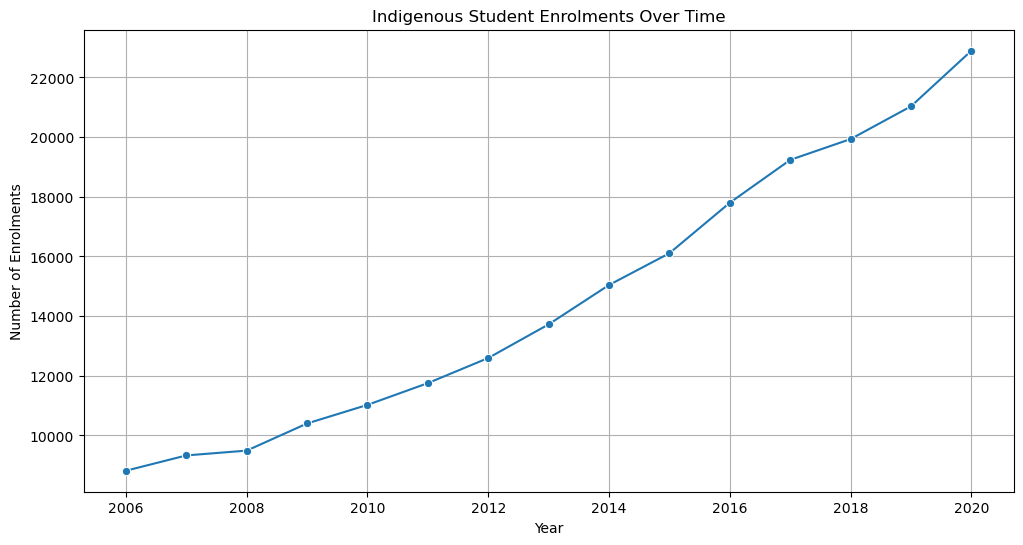

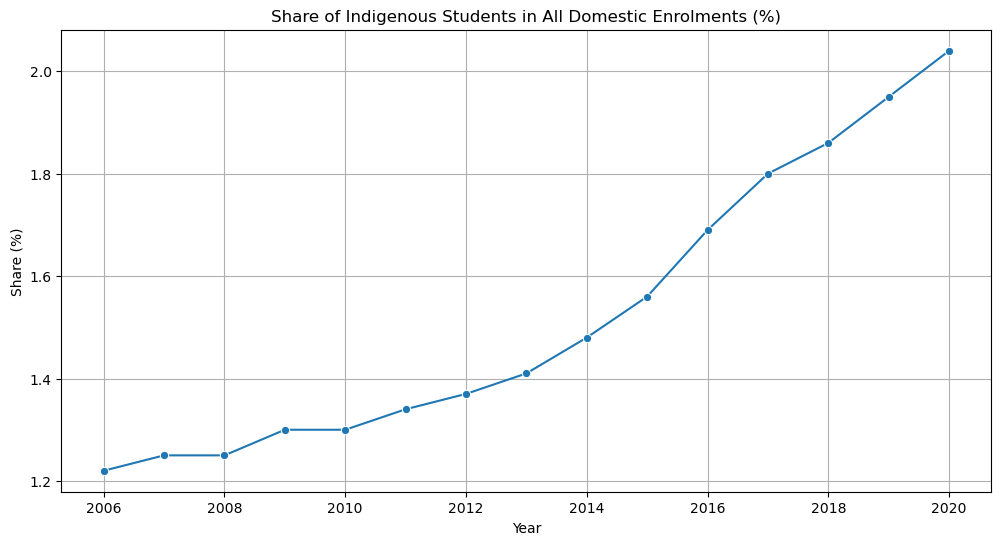

Plotting enrolments by course level...


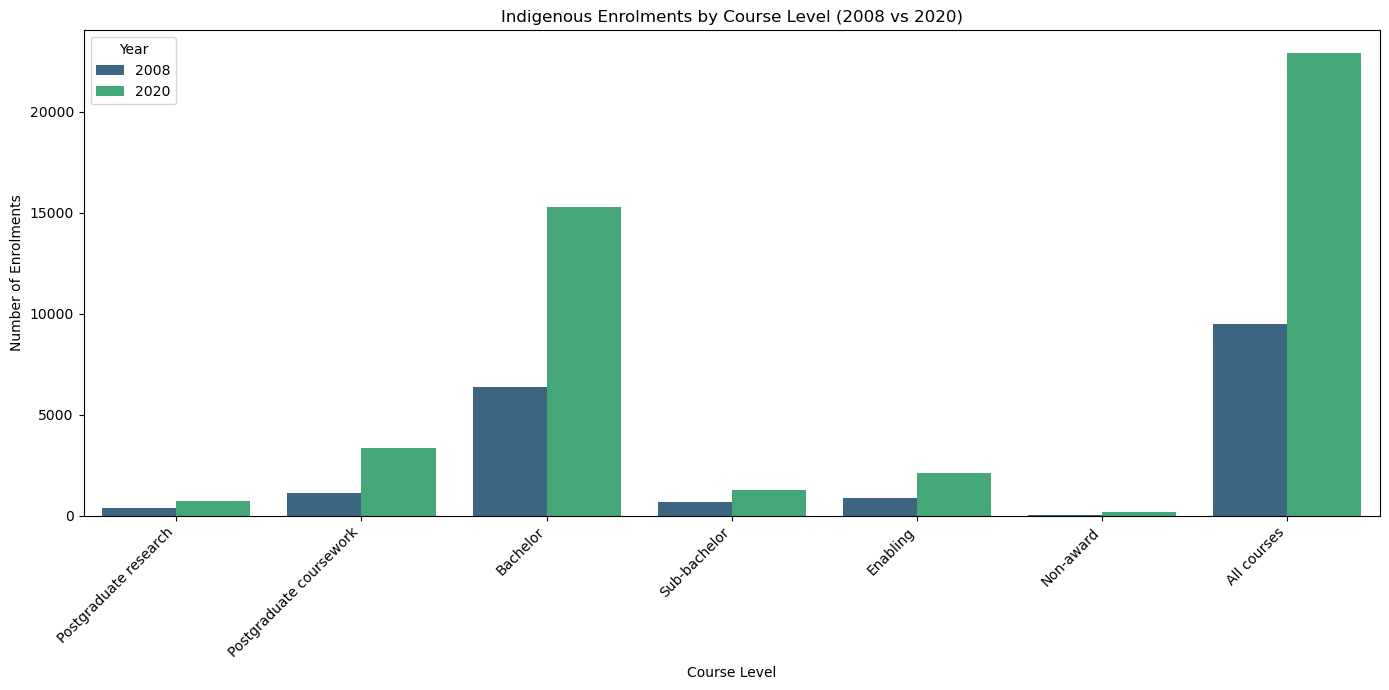

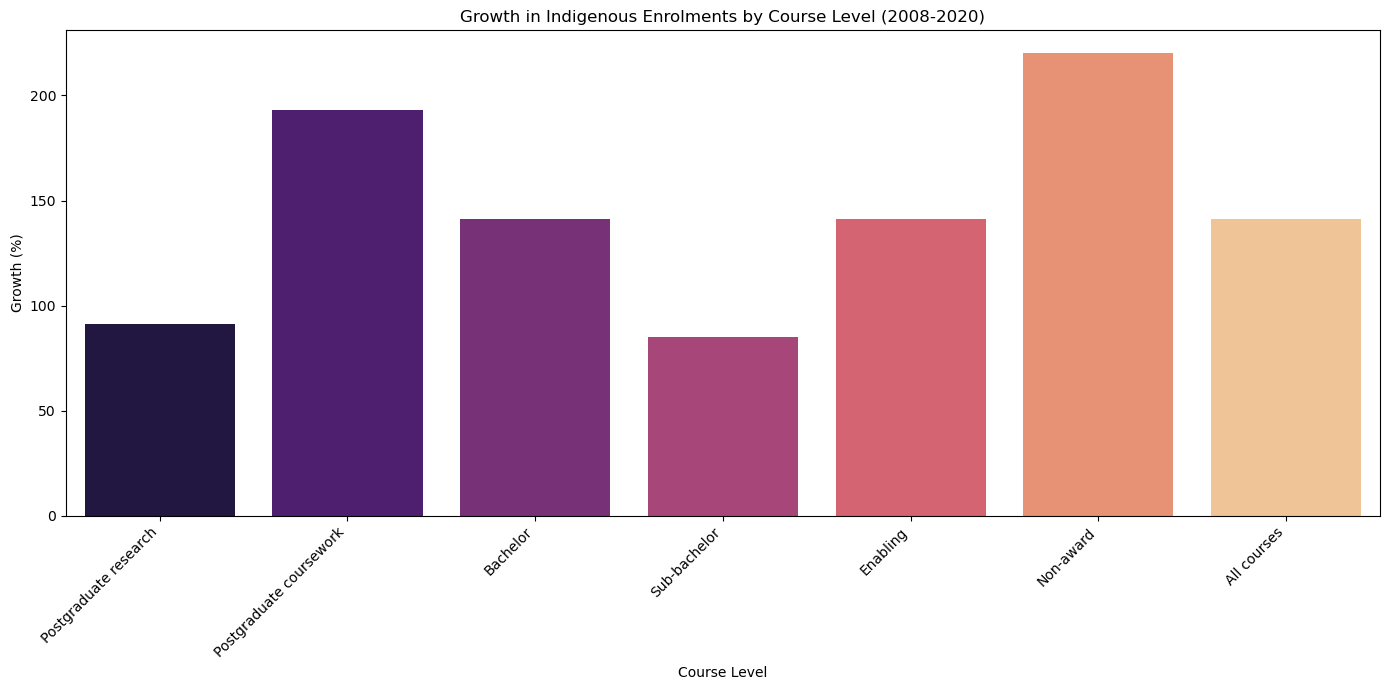

Plotting undergraduate applications growth...


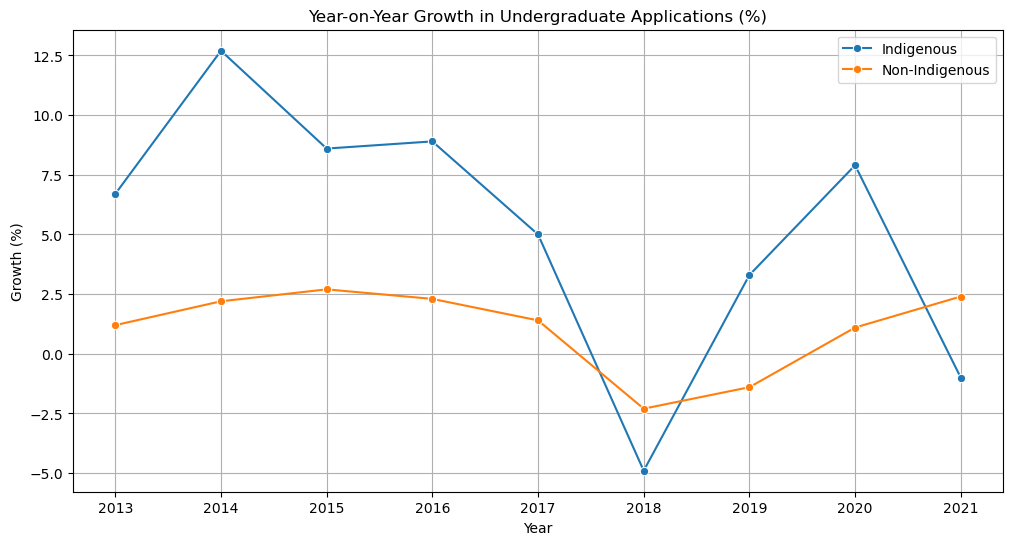

Plotting bachelor completion rates...


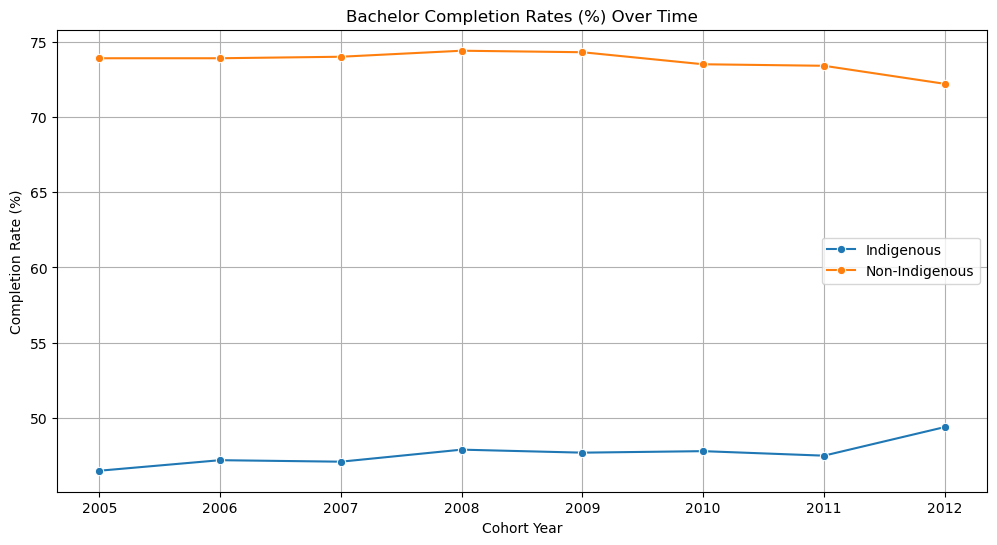

Plotting share of indigenous staff...


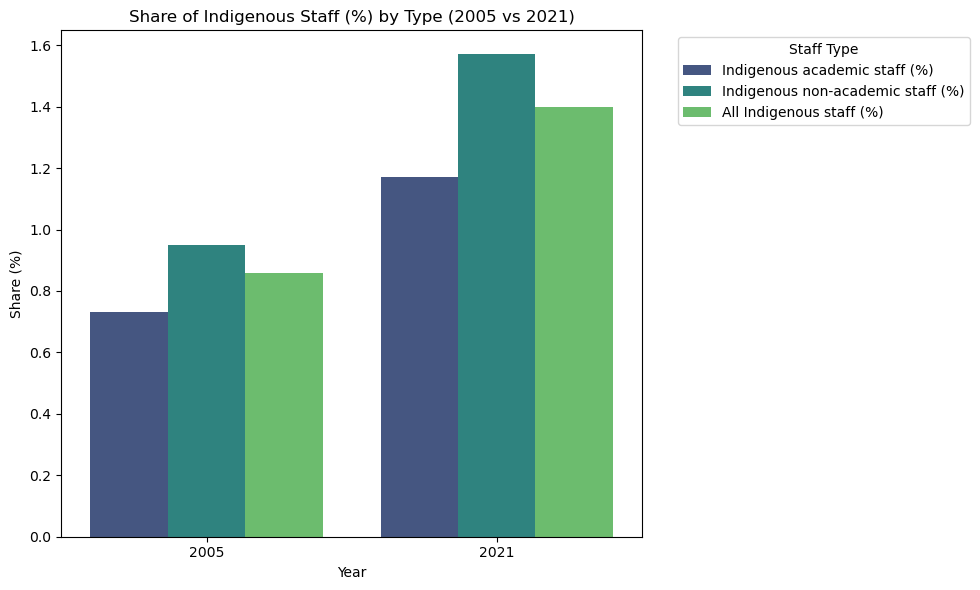

Plotting indigenous staff by duties...


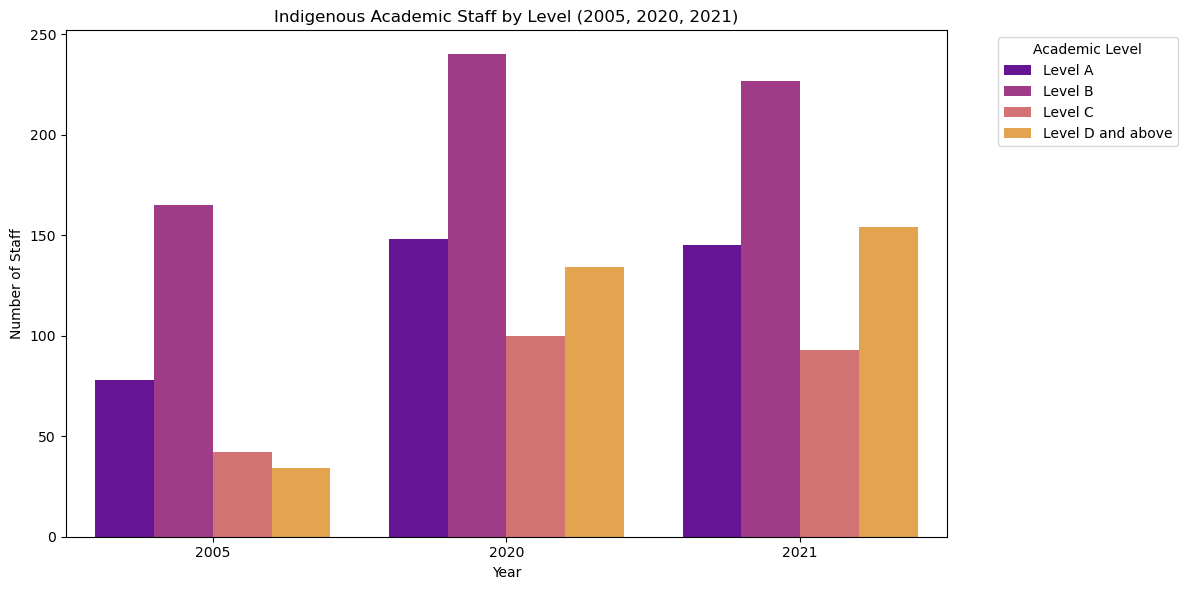

Plotting staff under 40...


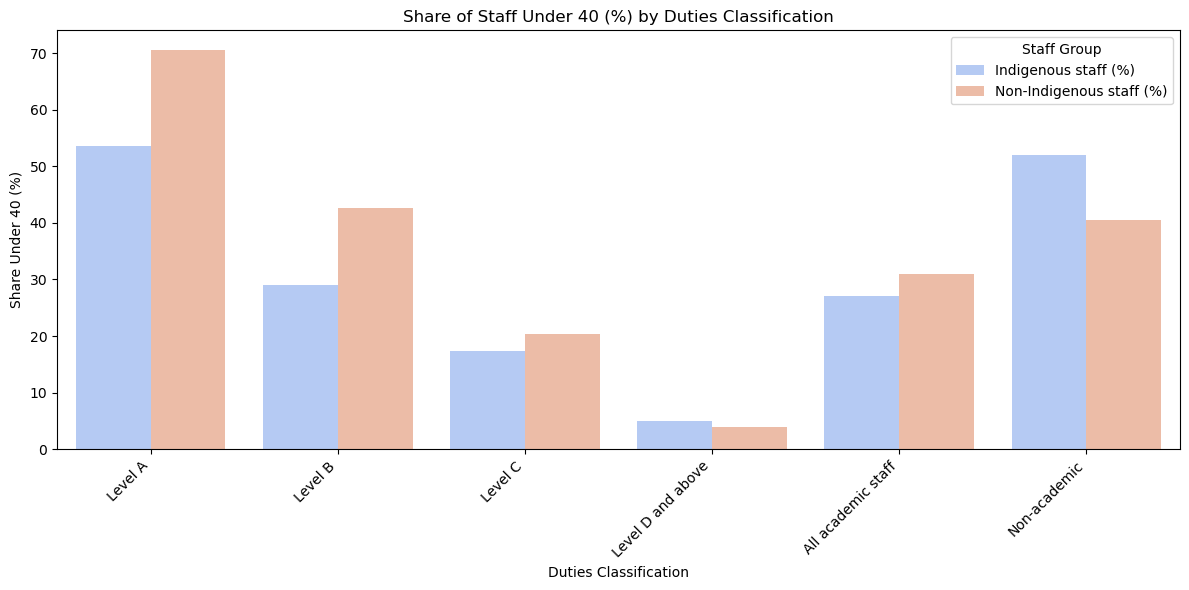

In [ ]:
# Analyze Indigenous student enrolments over time
if 'indigenous_enrolments' in indeginous_dataframes:
    enrolments_df = indeginous_dataframes['indigenous_enrolments']
    print("Plotting Indigenous enrolments over time...")
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=enrolments_df, x='Year', y='Indigenous student enrolments', marker='o')
    plt.title('Indigenous Student Enrolments Over Time')
    plt.xlabel('Year')
    plt.ylabel('Number of Enrolments')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=enrolments_df, x='Year', y='Share of all domestic enrolments (%)', marker='o')
    plt.title('Share of Indigenous Students in All Domestic Enrolments (%)')
    plt.xlabel('Year')
    plt.ylabel('Share (%)')
    plt.grid(True)
    plt.show()
else:
    print("DataFrame 'indigenous_enrolments' not found.")


# 2. Analyze enrolments by course level
if 'enrolments_by_course_level' in indeginous_dataframes:
    enrolments_level_df = indeginous_dataframes['enrolments_by_course_level']
    print("Plotting enrolments by course level...")
    # Melt the DataFrame for easier plotting of 2008 and 2020 data
    enrolments_level_melted = enrolments_level_df.melt(
        id_vars='Course level',
        value_vars=['2008', '2020'],
        var_name='Year',
        value_name='Number of Enrolments'
    )

    plt.figure(figsize=(14, 7))
    sns.barplot(data=enrolments_level_melted, x='Course level', y='Number of Enrolments', hue='Year', palette='viridis')
    plt.title('Indigenous Enrolments by Course Level (2008 vs 2020)')
    plt.xlabel('Course Level')
    plt.ylabel('Number of Enrolments')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Visualize Growth since 2008 (%)
    plt.figure(figsize=(14, 7))
    sns.barplot(data=enrolments_level_df, x='Course level', y='Growth since 2008 (%)', palette='magma')
    plt.title('Growth in Indigenous Enrolments by Course Level (2008-2020)')
    plt.xlabel('Course Level')
    plt.ylabel('Growth (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

else:
    print("DataFrame 'enrolments_by_course_level' not found.")

# 3. Analyze undergraduate applications growth over years
if 'undergrad_applications_growth' in indeginous_dataframes:
    undergrad_applications_growth_df = indeginous_dataframes['undergrad_applications_growth']
    print("Plotting undergraduate applications growth...")
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=undergrad_applications_growth_df, x='Year', y='Indigenous (%)', marker='o', label='Indigenous')
    sns.lineplot(data=undergrad_applications_growth_df, x='Year', y='Non-Indigenous (%)', marker='o', label='Non-Indigenous')
    plt.title('Year-on-Year Growth in Undergraduate Applications (%)')
    plt.xlabel('Year')
    plt.ylabel('Growth (%)')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
     print("DataFrame 'undergrad_applications_growth' not found.")


# 4. Analyze bachelor completion rates comparison
if 'bachelor_completion_rates' in indeginous_dataframes:
    bachelor_completion_rates_df = indeginous_dataframes['bachelor_completion_rates']
    print("Plotting bachelor completion rates...")
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=bachelor_completion_rates_df, x='Cohort', y='Indigenous students (%)', marker='o', label='Indigenous')
    sns.lineplot(data=bachelor_completion_rates_df, x='Cohort', y='Non-Indigenous students (%)', marker='o', label='Non-Indigenous')
    plt.title('Bachelor Completion Rates (%) Over Time')
    plt.xlabel('Cohort Year')
    plt.ylabel('Completion Rate (%)')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("DataFrame 'bachelor_completion_rates' not found.")

# 5. Analyze staff data
if 'share_of_indigenous_staff' in indeginous_dataframes:
    share_of_indigenous_staff_df = indeginous_dataframes['share_of_indigenous_staff']
    print("Plotting share of indigenous staff...")
    share_of_indigenous_staff_melted = share_of_indigenous_staff_df.melt(
        id_vars='Year',
        value_vars=['Indigenous academic staff (%)', 'Indigenous non-academic staff (%)', 'All Indigenous staff (%)'],
        var_name='Staff Type',
        value_name='Share (%)'
    )
    plt.figure(figsize=(10, 6))
    sns.barplot(data=share_of_indigenous_staff_melted, x='Year', y='Share (%)', hue='Staff Type', palette='viridis')
    plt.title('Share of Indigenous Staff (%) by Type (2005 vs 2021)')
    plt.xlabel('Year')
    plt.ylabel('Share (%)')
    plt.legend(title='Staff Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'share_of_indigenous_staff' not found.")


if 'indigenous_staff_by_duties' in indeginous_dataframes:
    indigenous_staff_by_duties_df = indeginous_dataframes['indigenous_staff_by_duties']
    print("Plotting indigenous staff by duties...")
    # Melt for plotting academic staff levels
    academic_staff_melted = indigenous_staff_by_duties_df.melt(
        id_vars='Year',
        value_vars=['Level A', 'Level B', 'Level C', 'Level D and above'],
        var_name='Academic Level',
        value_name='Number of Staff'
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(data=academic_staff_melted, x='Year', y='Number of Staff', hue='Academic Level', palette='plasma')
    plt.title('Indigenous Academic Staff by Level (2005, 2020, 2021)')
    plt.xlabel('Year')
    plt.ylabel('Number of Staff')
    plt.legend(title='Academic Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'indigenous_staff_by_duties' not found.")


if 'staff_under_40' in indeginous_dataframes:
    staff_under_40_df = indeginous_dataframes['staff_under_40']
    print("Plotting staff under 40...")
    staff_under_40_melted = staff_under_40_df.melt(
        id_vars='Duties classification',
        value_vars=['Indigenous staff (%)', 'Non-Indigenous staff (%)'],
        var_name='Staff Group',
        value_name='Share Under 40 (%)'
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(data=staff_under_40_melted, x='Duties classification', y='Share Under 40 (%)', hue='Staff Group', palette='coolwarm')
    plt.title('Share of Staff Under 40 (%) by Duties Classification')
    plt.xlabel('Duties Classification')
    plt.ylabel('Share Under 40 (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'staff_under_40' not found.")

# Report on Indigenous Strategies in Australian Universities

Based on the analysis of the provided dataframes, here are the key patterns, trends, and insights regarding Indigenous strategies in Australian universities:

## Patterns and Trends:

### 1. Indigenous Student Enrolments:
- **Consistent Growth:** Indigenous student enrolments have shown a clear and consistent upward trend from 2006 to 2020.
- **Increasing Share:** The share of Indigenous students in all domestic enrolments has also steadily increased over the same period, indicating that Indigenous student participation is growing at a faster rate than non-Indigenous domestic enrolments.

### 2. Enrolments by Course Level:
- **Growth Across All Levels:** Indigenous enrolments have grown significantly across all course levels between 2008 and 2020.
- **Higher Growth in Postgraduate and Sub-bachelor:** Postgraduate coursework and sub-bachelor levels have experienced particularly high growth rates compared to other course levels. This suggests increasing access and participation in these specific areas.

### 3. Undergraduate Applications Growth:
- **Volatility in Indigenous Applications:** The year-on-year growth in Indigenous undergraduate applications has been more volatile than that of non-Indigenous applications. There were notable peaks in growth in 2014 and 2020, but also a decrease in 2018 and 2021. This volatility might reflect the impact of specific initiatives, policy changes, or external factors affecting Indigenous applicants.

### 4. Bachelor Completion Rates:
- **Persistent Completion Gap:** A significant and persistent gap exists between the bachelor completion rates of Indigenous students (consistently around 46-49%) and non-Indigenous students (around 72-74%). While Indigenous completion rates have shown some fluctuation, the gap has not narrowed substantially over the observed cohort years (2005-2012). This highlights a major challenge in Indigenous education strategies.

### 5. Indigenous Staff Data:
- **Increased Share of Indigenous Staff:** The share of Indigenous staff (both academic and non-academic) has increased from 2005 to 2021, indicating progress in Indigenous employment within universities.
- **Growth in Academic Staff:** The number of Indigenous academic staff has increased across all levels (Level A to Level D and above) from 2005 to 2021. There is a notable increase in staff at higher levels (Level D and above), suggesting progress in career progression and representation in senior academic roles.
- **Staff Under 40:** A higher percentage of Indigenous non-academic staff are under 40 compared to non-Indigenous non-academic staff. For academic staff, the pattern varies by level, with a higher percentage of Indigenous staff under 40 at Level A but lower percentages at higher levels compared to their non-Indigenous counterparts. This could indicate differences in recruitment patterns or career trajectories.

## Summary and Interpretation:

The analysis reveals that Australian universities have made significant progress in increasing Indigenous student enrolments and the representation of Indigenous staff. The consistent growth in enrolments and their increasing share of the domestic student body are positive indicators of improved access and participation. The growth in postgraduate and sub-bachelor enrolments suggests that strategies are reaching a broader range of students and educational pathways.

However, the data also highlights significant challenges that persist. The most prominent challenge is the substantial gap in bachelor completion rates between Indigenous and non-Indigenous students. This suggests that while getting Indigenous students into university is improving, there are ongoing issues related to student support, retention, and successful completion of degrees. Addressing this completion gap is crucial for achieving true equity in educational outcomes.

The volatility in undergraduate application growth for Indigenous students warrants further investigation to understand the underlying causes and develop more stable and effective recruitment strategies.

While the increase in Indigenous staff numbers and their representation at higher academic levels is encouraging, the data on staff under 40 suggests potential differences in career progression or recruitment strategies across different staff categories and levels.

In conclusion, the data indicates a mixed picture of progress and persistent challenges in Indigenous strategies in Australian universities. While efforts to increase access and participation are showing positive results, more focused and effective strategies are needed to improve student success and completion rates, and to ensure equitable career progression for Indigenous staff.